# 통신데이터 분기별 EDA

월별 EDA는 `my_eda_월별EDA_백업.ipynb`에 따로 보관하고, 이 노트북은 월별 EDA에서 확인한 흐름을 **분기 기준**으로 다시 정리한 버전이다.

아직 최종 산출물 확정 단계가 아니므로 여기서는 `최종`이라는 표현 대신 **모델링 1차 후보**, **보조지표 후보**로 관리한다.

## 분석 기준

| 항목 | 기준 |
|---|---|
| 시간 단위 | 분기 |
| 공간 단위 | 행정동 |
| 기본 마스터 키 후보 | `base_quarter + admi_cd` |
| 기본 확인 테이블 | `T24` |
| 보조지표 테이블 | `T22`, `T26`, `T13`, `T25`, 필요 시 `T27` |
| 해석 원칙 | `CNT`는 통신 기반 관측 규모, `PURPOSE`와 `TRANS_GB`는 통신사 추정 보조지표 |

분기 기준으로 바꾸는 이유는 월별 급등락을 조금 완화하고, 이후 다른 팀원 지표와 합칠 때 샘플 단위를 단순하게 맞추기 위해서다.

## T데이터 활용 방향과 시각화 산출물

노트북의 기본 축은 행정동-분기 단위로 안정적으로 붙일 수 있는 `T24`지만, 한 테이블에만 의존하지 않도록 `T22`, `T26`, `T13`, `T25`, `T27`을 보조 후보로 같이 확인한다. `T4~T14`, `T16`, `T23`은 전체 메타데이터와 분기 추세 옵션에서 구조를 확인하고, 모델링 변수는 행정동 단위 결합 가능성과 해석력을 기준으로 추린다.

| 사용 데이터 | 데이터 성격 | 이 노트북에서 확인한 내용 | 뽑은 시각화/산출물 |
|---|---|---|---|
| `T4~T14`, `T16`, `T23~T27` 전체 | 도착/출발/OD, 목적, 교통수단, 체류, 성연령 등 통신 T데이터 전체 구조 | 파일 존재 여부, 컬럼, 용량, 날짜 범위, 행정동/시군구 단위 여부 | 전체 T데이터 메타데이터 표, 필요 시 전체 분기별 추세 옵션 |
| `T24` | 행정동별 시간대 + 목적 유동인구 | 행정동별 기본 유동 규모, 인구 보정 유동 강도, 시간대/요일/목적 구성 | 최근 분기 TOP 행정동 막대그래프, 상위 행정동 분기 추세, 전체 행정동 히트맵, 구별 추세, 인구 규모 대비 산점도, 기간 변화량, 전분기 급변 TOP, 목적/시간대 보조 그래프 |
| `T22` | 행정동별 시간대 + 성별/연령 + 내외국인 구성 | 생산가능·소비 가능 연령층 proxy, 고령층 비중, 외국인 유동 구성 | 최근 분기 주요 행정동의 `20~40대`, `60대 이상`, `외국인` 구성 비중 막대그래프 |
| `T26` | 도착 행정동 기준 시간대 + 목적 + 교통수단 + 체류시간 | 체류형 상권 여부, 교통수단 접근성, 상업 목적 보조지표 | 이동수단/체류시간/목적 비중 보조 시각화, TOP 행정동 구성 비교 |
| `T13` | 행정동 OD 출발지-도착지 + 목적 | 외부 행정동에서 들어오는 유입 비중, 유입-유출 순압력 | 최근 분기 상위 행정동 경량 EDA로 외부유입비율·순유입 지표 표와 TOP 행정동 비교 그래프 산출 |
| `T25` | 시군구 OD + 시간대 + 목적 + 교통수단 | 구 단위 외부 유입 압력 보조 확인 | 시군구 단위 유입 압력 후보 지표로 관리, 필요 시 T13보다 가벼운 구 단위 비교 시각화로 확장 |
| `T27` | 출발 행정동 기준 시간대 + 목적 + 교통수단 + 체류시간 | 출발지 기준 이동수단/목적 구조 보완 | 현재는 후보 표에 남기고, T26 도착지 결과와 비교하는 보조 시각화 후보로 관리 |

T24로 기본 유동 규모를 잡고, T22로 생산가능·연령 구성, T26으로 체류·교통수단, T13/T25로 외부유입 압력을 보완했다

In [38]:
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

number_formatter = FuncFormatter(lambda x, pos: f"{x:,.0f}")
ratio_formatter = FuncFormatter(lambda x, pos: f"{x:.0%}")

DATA_DIR_CANDIDATES = [Path("data"), Path("Data"), Path("../data"), Path("../Data")]
DATA_DIR = next((path.resolve() for path in DATA_DIR_CANDIDATES if path.exists()), Path("data").resolve())

con = duckdb.connect()

# 대용량 전체 스캔은 기본 비활성화한다.
RUN_FULL_T_QUARTER_EDA = False
RUN_CANDIDATE_QUARTER_SUMMARY = False

# T26 최신 분기 TOP 행정동 목적/수단 보조지표는 기본 실행한다.
# 실행 시간이 길면 False로 바꾸고 T24 목적 시각화만 먼저 확인한다.
RUN_T26_TRANSPORT_AUXILIARY_EDA = True

In [39]:
T_DATA_FILES = {
    "T4":  {"file": "t4_2023_2025_all_date_final.parquet",  "format": "parquet", "unit": "시군구", "meaning": "도착지 + 목적", "decision": "구조 파악 / 보조"},
    "T5":  {"file": "t5_2023_2025_all_date_final.parquet",  "format": "parquet", "unit": "행정동", "meaning": "도착지 + 목적", "decision": "구조 파악 / 보조"},
    "T6":  {"file": "t6_2023_2025_all_date_final.parquet",  "format": "parquet", "unit": "시군구", "meaning": "도착지 + 교통수단", "decision": "구조 파악 / 보조"},
    "T7":  {"file": "t7_2023_2025_all_date_final.parquet",  "format": "parquet", "unit": "행정동", "meaning": "도착지 + 교통수단", "decision": "구조 파악 / 보조"},
    "T8":  {"file": "t8_2023_2025_all_date_final.parquet",  "format": "parquet", "unit": "시군구", "meaning": "출발지 + 목적", "decision": "구조 파악 / 보조"},
    "T9":  {"file": "t9_2023_2025_all_date_final.parquet",  "format": "parquet", "unit": "행정동", "meaning": "출발지 + 목적", "decision": "구조 파악 / 보조"},
    "T10": {"file": "t10_2023_2025_all_date_final.parquet", "format": "parquet", "unit": "시군구", "meaning": "출발지 + 교통수단", "decision": "구조 파악 / 보조"},
    "T11": {"file": "t11_2023_2025_all_date_final.parquet", "format": "parquet", "unit": "행정동", "meaning": "출발지 + 교통수단", "decision": "구조 파악 / 보조"},
    "T12": {"file": "t12_2023_2025_all_final_v2.parquet",   "format": "parquet", "unit": "시군구 OD", "meaning": "출발지->도착지 + 목적", "decision": "구조 파악 / 보조"},
    "T13": {"file": "t13_2023_2025_all_final_v2.parquet",   "format": "parquet", "unit": "행정동 OD", "meaning": "출발지->도착지 + 목적", "decision": "후보: 행정동 OD 유입/유출"},
    "T14": {"file": "t14_2023_2025_all_final_v2.parquet",   "format": "parquet", "unit": "시군구 OD", "meaning": "출발지->도착지 + 교통수단", "decision": "구조 파악 / 보조"},
    "T16": {"file": "t16_2023_2025_all_date_final.parquet", "format": "parquet", "unit": "시군구", "meaning": "도착지 + 목적 + 체류시간", "decision": "구조 파악 / 보조"},
    "T20": {"file": "t20_2023_2025_all_date_final.csv",     "format": "csv", "unit": "기타", "meaning": "통합 CSV 참고 파일", "decision": "참고용"},
    "T21": {"file": "t21_2023_2025_all_date_final.csv",     "format": "csv", "unit": "기타", "meaning": "통합 CSV 참고 파일", "decision": "참고용"},
    "T22": {"file": "t22_2023_2025_all_date_final.parquet", "format": "parquet", "unit": "행정동", "meaning": "시간대 + 성별/연령 + 내외국인", "decision": "보조 후보"},
    "T23": {"file": "t23_2023_2025_all_date_final.parquet", "format": "parquet", "unit": "시군구", "meaning": "시간대 + 목적 유동인구", "decision": "구조 파악 / 보조"},
    "T24": {"file": "t24_2023_2025_all_date_final.parquet", "format": "parquet", "unit": "행정동", "meaning": "시간대 + 목적 유동인구", "decision": "기본 feature 후보"},
    "T25": {"file": "t25_2023_2025_all_final_v2.parquet",   "format": "parquet", "unit": "시군구 OD", "meaning": "출발지->도착지 + 시간대 + 목적 + 교통수단", "decision": "후보: 시군구 유입 압력"},
    "T26": {"file": "t26_2023_2025_all_final.parquet",      "format": "parquet", "unit": "행정동", "meaning": "도착지 + 시간대 + 목적 + 교통수단 + 체류시간", "decision": "후보: 체류/수단 보조지표"},
    "T27": {"file": "t27_2023_2025_all_final.parquet",      "format": "parquet", "unit": "행정동", "meaning": "출발지 + 시간대 + 목적 + 교통수단 + 체류시간", "decision": "후보: 출발지 수단 보조지표"},
}

table_inventory = pd.DataFrame([{"table": table, **info} for table, info in T_DATA_FILES.items()])
table_inventory

,table,file,format,unit,meaning,decision
0,T4,t4_2023_2025_all_date_final.parquet,parquet,시군구,도착지 + 목적,구조 파악 / 보조
1,T5,t5_2023_2025_all_date_final.parquet,parquet,행정동,도착지 + 목적,구조 파악 / 보조
2,T6,t6_2023_2025_all_date_final.parquet,parquet,시군구,도착지 + 교통수단,구조 파악 / 보조
3,T7,t7_2023_2025_all_date_final.parquet,parquet,행정동,도착지 + 교통수단,구조 파악 / 보조
4,T8,t8_2023_2025_all_date_final.parquet,parquet,시군구,출발지 + 목적,구조 파악 / 보조
5,T9,t9_2023_2025_all_date_final.parquet,parquet,행정동,출발지 + 목적,구조 파악 / 보조
6,T10,t10_2023_2025_all_date_final.parquet,parquet,시군구,출발지 + 교통수단,구조 파악 / 보조
7,T11,t11_2023_2025_all_date_final.parquet,parquet,행정동,출발지 + 교통수단,구조 파악 / 보조
8,T12,t12_2023_2025_all_final_v2.parquet,parquet,시군구 OD,출발지->도착지 + 목적,구조 파악 / 보조
9,T13,t13_2023_2025_all_final_v2.parquet,parquet,행정동 OD,출발지->도착지 + 목적,후보: 행정동 OD 유입/유출


In [40]:
def p(path):
    return str(Path(path).resolve()).replace("\\", "/")


def scan_sql(table):
    info = T_DATA_FILES[table]
    path = p(DATA_DIR / info["file"])
    if info["format"] == "csv":
        return f"read_csv_auto('{path}', header=true)"
    return f"read_parquet('{path}')"


def q(sql):
    return con.execute(sql).fetchdf()


_COL_CACHE = {}


def table_columns(table):
    if table not in _COL_CACHE:
        _COL_CACHE[table] = con.execute(f"DESCRIBE SELECT * FROM {scan_sql(table)}").fetchdf()["column_name"].tolist()
    return _COL_CACHE[table]


def qname(col):
    return '"' + col.replace('"', '""') + '"'


def cnt_expr(table):
    cols = table_columns(table)
    if "CNT" in cols:
        return "CNT"
    cnt_cols = [c for c in cols if c.endswith("_CNT")]
    if cnt_cols:
        return " + ".join(qname(c) for c in cnt_cols)
    return "NULL"


def date_expr(table):
    cols = table_columns(table)
    if "ETL_YMD" in cols:
        return "COALESCE(TRY_CAST(ETL_YMD AS DATE), TRY_STRPTIME(CAST(ETL_YMD AS VARCHAR), '%Y%m%d'), TRY_STRPTIME(CAST(ETL_YMD AS VARCHAR), '%Y%m'))"
    if "ETL_YM" in cols:
        return "COALESCE(TRY_CAST(ETL_YM AS DATE), TRY_STRPTIME(CAST(ETL_YM AS VARCHAR), '%Y%m'))"
    return None


def quarter_start_expr(date_sql):
    return "CAST(date_trunc('quarter', " + date_sql + ") AS DATE)"


def quarter_label_expr(date_sql):
    return (
        "CAST(EXTRACT(year FROM " + date_sql + ") AS VARCHAR) || '-Q' || "
        "CAST(EXTRACT(quarter FROM " + date_sql + ") AS VARCHAR)"
    )


def make_quarter_calendar(start, end):
    periods = pd.period_range(pd.Timestamp(start).to_period("Q"), pd.Timestamp(end).to_period("Q"), freq="Q")
    calendar = pd.DataFrame({"QUARTER_START": periods.to_timestamp()})
    calendar["YEAR"] = calendar["QUARTER_START"].dt.year
    calendar["QUARTER"] = calendar["QUARTER_START"].dt.quarter
    calendar["base_quarter"] = calendar["YEAR"].astype(str) + "-Q" + calendar["QUARTER"].astype(str)
    calendar["quarter_axis_label"] = calendar["YEAR"].astype(str) + "\nQ" + calendar["QUARTER"].astype(str)
    return calendar


def add_year_quarter_columns(df, date_col="QUARTER_START"):
    out = df.copy()
    out["YEAR"] = pd.to_datetime(out[date_col]).dt.year
    out["QUARTER"] = pd.to_datetime(out[date_col]).dt.quarter
    out["YEAR_QUARTER"] = out["YEAR"].astype(str) + "-Q" + out["QUARTER"].astype(str)
    out["YEAR_QUARTER_LABEL"] = out["YEAR"].astype(str) + "년 " + out["QUARTER"].astype(str) + "분기"
    return out


def union_query(parts):
    return "\nUNION ALL\n".join(parts)


def read_csv_with_fallback(path):
    for enc in ["cp949", "utf-8-sig", "euc-kr", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

## 인구 데이터 분기 기준 정리

`population_total.csv`의 `총인구수`는 행정동별 등록 인구로 보고, 분기별 평균 인구를 만들어 통신 `CNT`를 보정한다.

여기서 `CNT_PER_1K_POP`은 실제 1,000명이 몇 번 방문했다는 뜻이 아니라, **등록 인구 1,000명당 통신 관측 규모**를 비교하기 쉽게 바꾼 상대 지표다.

분기 인구는 월별 인구를 평균낸 값이라 `TOTAL_POP`이 소수점으로 표시될 수 있다. 이는 집계 오류가 아니라 월별 평균을 쓴 결과이며, 비율 계산에는 평균값을 그대로 사용한다.


In [41]:
population_raw = read_csv_with_fallback(DATA_DIR / "population_total.csv")

population_clean = population_raw.rename(
    columns={
        "행정구역": "REGION_NM",
        "행정동 코드": "ADMI_CD_RAW",
        "날짜": "YEAR_MONTH",
        "총인구수": "TOTAL_POP",
        "세대수": "HOUSEHOLDS",
        "세대당_인구": "HOUSEHOLD_SIZE",
    }
).copy()

population_clean["TOTAL_POP"] = (
    population_clean["TOTAL_POP"].astype(str).str.replace(",", "", regex=False).astype(float)
)
population_clean["HOUSEHOLDS"] = (
    population_clean["HOUSEHOLDS"].astype(str).str.replace(",", "", regex=False).astype(float)
)
population_clean["BASE_MONTH"] = pd.to_datetime(population_clean["YEAR_MONTH"] + "-01")
population_clean["QUARTER_START"] = population_clean["BASE_MONTH"].dt.to_period("Q").dt.start_time
population_clean["base_quarter"] = (
    population_clean["BASE_MONTH"].dt.year.astype(str)
    + "-Q"
    + population_clean["BASE_MONTH"].dt.quarter.astype(str)
)

# 인구 파일의 행정동 코드는 10자리, 통신 데이터의 행정동 코드는 8자리라서 뒤 두 자리를 제거한다.
population_clean["ADMI_CD"] = (population_clean["ADMI_CD_RAW"].astype("int64") // 100).astype("int64")

region_parts = population_clean["REGION_NM"].str.split()
population_clean["CTY_NM"] = region_parts.apply(lambda x: " ".join(x[1:3]) if len(x) >= 4 else None)
population_clean["ADMI_NM"] = region_parts.apply(lambda x: x[-1] if len(x) else None)

population_quarterly = (
    population_clean.groupby(["QUARTER_START", "base_quarter", "ADMI_CD", "CTY_NM", "ADMI_NM"], as_index=False)
    .agg(
        TOTAL_POP=("TOTAL_POP", "mean"),
        HOUSEHOLDS=("HOUSEHOLDS", "mean"),
        HOUSEHOLD_SIZE=("HOUSEHOLD_SIZE", "mean"),
    )
)

population_quarterly.head()

,QUARTER_START,base_quarter,ADMI_CD,CTY_NM,ADMI_NM,TOTAL_POP,HOUSEHOLDS,HOUSEHOLD_SIZE
0,2023-01-01,2023-Q1,41131510,성남시 수정구,신흥1동,13124.000000,7925.333333,1.656667
1,2023-01-01,2023-Q1,41131520,성남시 수정구,신흥2동,19874.666667,7619.000000,2.610000
2,2023-01-01,2023-Q1,41131530,성남시 수정구,신흥3동,11195.000000,6537.333333,1.713333
3,2023-01-01,2023-Q1,41131540,성남시 수정구,태평1동,14973.000000,8774.000000,1.710000
4,2023-01-01,2023-Q1,41131550,성남시 수정구,태평2동,14896.000000,7905.000000,1.883333


## 전체 t 데이터 분기 기준 메타데이터

먼저 전체 파일 목록, 컬럼, 핵심 코드 존재 여부를 확인한다. 실제 모델 후보 판단은 아래 분기별 행정동 EDA와 보조지표 EDA를 기준으로 한다.

In [42]:
metadata_rows = []
schema_rows = []

for table, info in T_DATA_FILES.items():
    path = DATA_DIR / info["file"]
    cols = table_columns(table)
    metadata_rows.append(
        {
            "table": table,
            "file": info["file"],
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / 1024 / 1024, 1) if path.exists() else np.nan,
            "unit": info["unit"],
            "meaning": info["meaning"],
            "decision": info["decision"],
            "has_cnt": "CNT" in cols or any(c.endswith("_CNT") for c in cols),
            "has_purpose": "PURPOSE" in cols,
            "has_transport": "TRANS_GB" in cols,
            "has_duration": "DURATION" in cols,
            "admin_cols": ", ".join([c for c in ["ADMI_CD", "D_ADMI_CD", "O_ADMI_CD"] if c in cols]),
        }
    )
    for col in cols:
        schema_rows.append({"table": table, "column": col})

t_table_metadata = pd.DataFrame(metadata_rows)
schema_by_table = pd.DataFrame(schema_rows)
t_table_metadata

,table,file,exists,size_mb,unit,meaning,decision,has_cnt,has_purpose,has_transport,has_duration,admin_cols
0,T4,t4_2023_2025_all_date_final.parquet,True,8.4,시군구,도착지 + 목적,구조 파악 / 보조,True,True,False,False,
1,T5,t5_2023_2025_all_date_final.parquet,True,253.3,행정동,도착지 + 목적,구조 파악 / 보조,True,True,False,False,D_ADMI_CD
2,T6,t6_2023_2025_all_date_final.parquet,True,12.6,시군구,도착지 + 교통수단,구조 파악 / 보조,True,False,True,False,
3,T7,t7_2023_2025_all_date_final.parquet,True,386.0,행정동,도착지 + 교통수단,구조 파악 / 보조,True,False,True,False,D_ADMI_CD
4,T8,t8_2023_2025_all_date_final.parquet,True,10.6,시군구,출발지 + 목적,구조 파악 / 보조,True,True,False,False,
5,T9,t9_2023_2025_all_date_final.parquet,True,289.4,행정동,출발지 + 목적,구조 파악 / 보조,True,True,False,False,O_ADMI_CD
6,T10,t10_2023_2025_all_date_final.parquet,True,12.9,시군구,출발지 + 교통수단,구조 파악 / 보조,True,False,True,False,
7,T11,t11_2023_2025_all_date_final.parquet,True,403.4,행정동,출발지 + 교통수단,구조 파악 / 보조,True,False,True,False,O_ADMI_CD
8,T12,t12_2023_2025_all_final_v2.parquet,True,42.9,시군구 OD,출발지->도착지 + 목적,구조 파악 / 보조,True,True,False,False,
9,T13,t13_2023_2025_all_final_v2.parquet,True,3538.0,행정동 OD,출발지->도착지 + 목적,후보: 행정동 OD 유입/유출,True,True,False,False,"D_ADMI_CD, O_ADMI_CD"


## 전체 t 데이터 분기별 추세 옵션

전체 T4~T27을 모두 분기별로 합치면 구조는 잘 보이지만, T13/T25/T26/T27이 커서 시간이 오래 걸린다. 필요할 때만 `RUN_FULL_T_QUARTER_EDA=True`로 바꿔 실행한다.

In [43]:
if RUN_FULL_T_QUARTER_EDA:
    quarterly_parts = []
    for table in T_DATA_FILES:
        d = date_expr(table)
        if d is None:
            continue
        quarterly_parts.append(f'''
            SELECT
                '{table}' AS table_name,
                {quarter_start_expr(d)} AS quarter_start,
                {quarter_label_expr(d)} AS base_quarter,
                SUM({cnt_expr(table)}) AS cnt_sum
            FROM {scan_sql(table)}
            GROUP BY 1, 2, 3
        ''')

    all_t_quarterly = q(union_query(quarterly_parts)).sort_values(["table_name", "quarter_start"])
else:
    all_t_quarterly = pd.DataFrame(
        {"안내": ["전체 t 데이터 분기별 추세는 대용량 스캔이라 기본 실행하지 않습니다. RUN_FULL_T_QUARTER_EDA=True로 바꾸면 실행됩니다."]}
    )

all_t_quarterly

,안내
0,전체 t 데이터 분기별 추세는 대용량 스캔이라 기본 실행하지 않습니다. RUN_FU...


In [44]:
if RUN_FULL_T_QUARTER_EDA and not all_t_quarterly.empty:
    all_t_quarterly_pivot = all_t_quarterly.pivot(index="base_quarter", columns="table_name", values="cnt_sum")
    ax = all_t_quarterly_pivot.plot(figsize=(14, 5), marker="o", title="전체 t 데이터 분기별 CNT 추세")
    ax.set_xlabel("분기")
    ax.set_ylabel("CNT 합계")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="table", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    pd.DataFrame({"안내": ["전체 t 데이터 추세 그래프는 RUN_FULL_T_QUARTER_EDA=True일 때 표시됩니다."]})

## 후보 테이블 분기별 요약 옵션

`T24`, `T13`, `T26`, `T27`, `T25`는 모델링 후보지만 일부 파일이 매우 크다. 전체 후보 테이블의 분기별 총량 비교가 필요하면 `RUN_CANDIDATE_QUARTER_SUMMARY=True`로 바꿔 실행한다.

In [45]:
CANDIDATE_TABLES = ["T24", "T13", "T26", "T27", "T25"]

if RUN_CANDIDATE_QUARTER_SUMMARY:
    candidate_quarterly_parts = []
    for table in CANDIDATE_TABLES:
        d = date_expr(table)
        candidate_quarterly_parts.append(f'''
            SELECT
                '{table}' AS table_name,
                {quarter_start_expr(d)} AS quarter_start,
                {quarter_label_expr(d)} AS base_quarter,
                COUNT(*) AS row_count,
                SUM({cnt_expr(table)}) AS cnt_sum
            FROM {scan_sql(table)}
            GROUP BY 1, 2, 3
        ''')

    candidate_quarterly_summary = q(union_query(candidate_quarterly_parts)).sort_values(["table_name", "quarter_start"])
else:
    candidate_quarterly_summary = pd.DataFrame(
        {"안내": ["후보 테이블 전체 분기 요약은 대용량 스캔이라 기본 실행하지 않습니다. 아래 T24 행정동 분기 EDA를 먼저 확인하세요."]}
    )

candidate_quarterly_summary

,안내
0,후보 테이블 전체 분기 요약은 대용량 스캔이라 기본 실행하지 않습니다. 아래 T24...


## T24 분기별 행정동 패널

월별 EDA에서 사용했던 핵심 흐름을 분기 단위로 바꾼다. 기본 테이블은 `T24`다.

`T24`를 먼저 보는 이유는 행정동 단위이고, 목적 코드와 시간대가 들어 있어서 상권 유동 규모와 시간대 특성을 가장 먼저 보기 좋기 때문이다.

In [46]:
t24_d = date_expr("T24")

t24_quarterly_admin_panel = q(f'''
    SELECT
        'T24' AS TABLE_ID,
        '행정동' AS ADMIN_ROLE,
        {quarter_start_expr(t24_d)} AS QUARTER_START,
        {quarter_label_expr(t24_d)} AS base_quarter,
        CAST(ADMI_CD AS BIGINT) AS ADMI_CD,
        SUM(CNT) AS CNT_SUM,
        SUM(CASE WHEN TRY_CAST(TIME_CD AS INTEGER) BETWEEN 0 AND 5 THEN CNT ELSE 0 END) AS NIGHT_CNT,
        SUM(CASE WHEN TRY_CAST(TIME_CD AS INTEGER) BETWEEN 11 AND 14 THEN CNT ELSE 0 END) AS LUNCH_CNT,
        SUM(CASE WHEN TRY_CAST(TIME_CD AS INTEGER) BETWEEN 17 AND 21 THEN CNT ELSE 0 END) AS EVENING_CNT
    FROM {scan_sql("T24")}
    WHERE ADMI_CD IS NOT NULL
    GROUP BY 1, 2, 3, 4, 5
''')

t24_quarterly_admin_panel["QUARTER_START"] = pd.to_datetime(t24_quarterly_admin_panel["QUARTER_START"])

t24_quarterly_admin_panel = t24_quarterly_admin_panel.merge(
    population_quarterly[
        ["QUARTER_START", "base_quarter", "ADMI_CD", "CTY_NM", "ADMI_NM", "TOTAL_POP", "HOUSEHOLDS", "HOUSEHOLD_SIZE"]
    ],
    on=["QUARTER_START", "base_quarter", "ADMI_CD"],
    how="inner",
)

t24_quarterly_admin_panel["CNT_PER_PERSON"] = t24_quarterly_admin_panel["CNT_SUM"] / t24_quarterly_admin_panel["TOTAL_POP"]
t24_quarterly_admin_panel["CNT_PER_1K_POP"] = t24_quarterly_admin_panel["CNT_PER_PERSON"] * 1000
t24_quarterly_admin_panel["CNT_PER_HOUSEHOLD"] = t24_quarterly_admin_panel["CNT_SUM"] / t24_quarterly_admin_panel["HOUSEHOLDS"]
t24_quarterly_admin_panel["NIGHT_RATIO"] = t24_quarterly_admin_panel["NIGHT_CNT"] / t24_quarterly_admin_panel["CNT_SUM"]
t24_quarterly_admin_panel["LUNCH_RATIO"] = t24_quarterly_admin_panel["LUNCH_CNT"] / t24_quarterly_admin_panel["CNT_SUM"]
t24_quarterly_admin_panel["EVENING_RATIO"] = t24_quarterly_admin_panel["EVENING_CNT"] / t24_quarterly_admin_panel["CNT_SUM"]

t24_quarterly_admin_panel = t24_quarterly_admin_panel.sort_values(["ADMI_CD", "QUARTER_START"])
t24_quarterly_admin_panel["CNT_QOQ_CHANGE"] = t24_quarterly_admin_panel.groupby("ADMI_CD")["CNT_SUM"].diff()
t24_quarterly_admin_panel["CNT_QOQ_PCT"] = t24_quarterly_admin_panel.groupby("ADMI_CD")["CNT_SUM"].pct_change()
t24_quarterly_admin_panel["CNT_PER_PERSON_QOQ_PCT"] = (
    t24_quarterly_admin_panel.groupby("ADMI_CD")["CNT_PER_PERSON"].pct_change()
)
t24_quarterly_admin_panel["CNT_PER_PERSON_MA2"] = (
    t24_quarterly_admin_panel.groupby("ADMI_CD")["CNT_PER_PERSON"]
    .transform(lambda s: s.rolling(2, min_periods=1).mean())
)
t24_quarterly_admin_panel = add_year_quarter_columns(t24_quarterly_admin_panel)

focus_table_id = "T24"
focus_admin_role = "행정동"
focus_quarterly_admin = t24_quarterly_admin_panel.copy()
quarter_calendar_df = make_quarter_calendar(
    focus_quarterly_admin["QUARTER_START"].min(),
    focus_quarterly_admin["QUARTER_START"].max(),
)
quarter_order = quarter_calendar_df["base_quarter"].tolist()
quarter_axis_labels = quarter_calendar_df["quarter_axis_label"].tolist()
quarter_label_map = dict(zip(quarter_calendar_df["base_quarter"], quarter_calendar_df["quarter_axis_label"]))

t24_quarterly_admin_panel.head()

,TABLE_ID,ADMIN_ROLE,QUARTER_START,base_quarter,ADMI_CD,CNT_SUM,NIGHT_CNT,LUNCH_CNT,EVENING_CNT,CTY_NM,ADMI_NM,TOTAL_POP,HOUSEHOLDS,HOUSEHOLD_SIZE,CNT_PER_PERSON,CNT_PER_1K_POP,CNT_PER_HOUSEHOLD,NIGHT_RATIO,LUNCH_RATIO,EVENING_RATIO,CNT_QOQ_CHANGE,CNT_QOQ_PCT,CNT_PER_PERSON_QOQ_PCT,CNT_PER_PERSON_MA2,YEAR,QUARTER,YEAR_QUARTER,YEAR_QUARTER_LABEL
371,T24,행정동,2023-01-01,2023-Q1,41131510,781803.43,35164.78,134400.55,336543.42,성남시 수정구,신흥1동,13124.000000,7925.333333,1.656667,59.570514,59570.514325,98.646126,0.044979,0.171911,0.430471,NaN,NaN,NaN,59.570514,2023,1,2023-Q1,2023년 1분기
390,T24,행정동,2023-04-01,2023-Q2,41131510,808998.65,38669.50,134219.02,348973.54,성남시 수정구,신흥1동,13035.333333,7888.000000,1.653333,62.061984,62061.984095,102.560681,0.047799,0.165908,0.431365,27195.22,0.034785,0.041824,60.816249,2023,2,2023-Q2,2023년 2분기
92,T24,행정동,2023-07-01,2023-Q3,41131510,807881.77,38351.40,138655.18,343515.44,성남시 수정구,신흥1동,12902.000000,7826.666667,1.650000,62.616786,62616.785770,103.221691,0.047472,0.171628,0.425205,-1116.88,-0.001381,0.008939,62.339385,2023,3,2023-Q3,2023년 3분기
540,T24,행정동,2023-10-01,2023-Q4,41131510,860145.94,39154.26,147600.23,369872.11,성남시 수정구,신흥1동,12735.000000,7739.333333,1.646667,67.541888,67541.887711,111.139539,0.045520,0.171599,0.430011,52264.17,0.064693,0.078655,65.079337,2023,4,2023-Q4,2023년 4분기
293,T24,행정동,2024-01-01,2024-Q1,41131510,779105.37,35095.01,139601.60,332699.17,성남시 수정구,신흥1동,12618.000000,7699.333333,1.640000,61.745552,61745.551593,101.191277,0.045045,0.179182,0.427027,-81040.57,-0.094217,-0.085818,64.643720,2024,1,2024-Q1,2024년 1분기


**데이터프레임 설명 - `t24_quarterly_admin_panel`**

`T24`를 분기별·행정동별로 집계한 뒤, 같은 분기의 평균 등록 인구를 붙인 기본 EDA 패널이다.

| 컬럼 | 의미 |
|---|---|
| `CNT_SUM` | 해당 분기·행정동의 T24 관측 규모 |
| `CNT_PER_1K_POP` | 등록 인구 1,000명당 T24 관측 규모 |
| `NIGHT_RATIO` | 0~5시 관측 비중 |
| `LUNCH_RATIO` | 11~14시 관측 비중 |
| `EVENING_RATIO` | 17~21시 관측 비중 |
| `CNT_PER_PERSON_QOQ_PCT` | 전분기 대비 인구 보정 관측 규모 변화율 |

In [47]:
quarter_admin_coverage = (
    focus_quarterly_admin.groupby(["TABLE_ID", "ADMIN_ROLE"], as_index=False)
    .agg(
        ROWS=("CNT_SUM", "size"),
        QUARTER_COUNT=("QUARTER_START", "nunique"),
        ADMI_COUNT=("ADMI_CD", "nunique"),
        CNT_SUM=("CNT_SUM", "sum"),
        AVG_CNT_PER_1K_POP=("CNT_PER_1K_POP", "mean"),
        MAX_CNT_PER_1K_POP=("CNT_PER_1K_POP", "max"),
    )
)

quarter_coverage_detail = (
    focus_quarterly_admin.groupby(["TABLE_ID", "YEAR", "QUARTER"], as_index=False)
    .agg(ADMI_COUNT=("ADMI_CD", "nunique"), CNT_SUM=("CNT_SUM", "sum"))
    .pivot_table(index=["TABLE_ID", "YEAR"], columns="QUARTER", values="ADMI_COUNT", fill_value=0)
    .rename(columns={1: "Q1", 2: "Q2", 3: "Q3", 4: "Q4"})
    .reindex(columns=["Q1", "Q2", "Q3", "Q4"], fill_value=0)
    .reset_index()
)
for col in ["Q1", "Q2", "Q3", "Q4"]:
    quarter_coverage_detail[col] = quarter_coverage_detail[col].astype("Int64")

display(quarter_admin_coverage)
quarter_coverage_detail

,TABLE_ID,ADMIN_ROLE,ROWS,QUARTER_COUNT,ADMI_COUNT,CNT_SUM,AVG_CNT_PER_1K_POP,MAX_CNT_PER_1K_POP
0,T24,행정동,600,12,50,1.561037e+09,147458.858993,1.000476e+06


QUARTER,TABLE_ID,YEAR,Q1,Q2,Q3,Q4
0,T24,2023,50,50,50,50
1,T24,2024,50,50,50,50
2,T24,2025,50,50,50,50


## 분기별 행정동 시각화

아래 그래프들은 월별 EDA의 흐름을 그대로 분기 단위로 바꾼 것이다.

해석 순서는 `최근 분기 TOP 행정동 -> 상위 행정동 분기 추세 -> 전체 행정동 히트맵 -> 인구 규모와 유동 강도 -> 기간 전체 변화 -> 전분기 급변` 순서로 보면 된다.

In [48]:
viz_df = focus_quarterly_admin.copy()
viz_latest_quarter = viz_df["QUARTER_START"].max()
viz_latest_quarter_label = viz_df.loc[viz_df["QUARTER_START"] == viz_latest_quarter, "base_quarter"].iloc[0]

viz_latest = viz_df[viz_df["QUARTER_START"] == viz_latest_quarter].copy()
viz_latest["LABEL"] = viz_latest["CTY_NM"] + " " + viz_latest["ADMI_NM"]

viz_top20 = viz_latest.sort_values("CNT_PER_1K_POP", ascending=False).head(20)
viz_top20[
    ["base_quarter", "CTY_NM", "ADMI_NM", "TOTAL_POP", "CNT_SUM", "CNT_PER_1K_POP", "NIGHT_RATIO", "LUNCH_RATIO", "EVENING_RATIO"]
]

,base_quarter,CTY_NM,ADMI_NM,TOTAL_POP,CNT_SUM,CNT_PER_1K_POP,NIGHT_RATIO,LUNCH_RATIO,EVENING_RATIO
111,2025-Q4,성남시 수정구,시흥동,3533.666667,2845036.36,805123.014810,0.018782,0.246424,0.133157
71,2025-Q4,성남시 분당구,삼평동,23609.666667,9644989.80,408518.677378,0.013502,0.215064,0.179204
184,2025-Q4,성남시 분당구,야탑1동,16517.333333,5865341.70,355102.217872,0.019327,0.284261,0.258412
433,2025-Q4,성남시 중원구,상대원2동,2923.333333,948795.10,324559.327252,0.035330,0.207617,0.302725
30,2025-Q4,성남시 분당구,서현1동,30615.000000,8789480.12,287097.178507,0.017878,0.268666,0.279167
73,2025-Q4,성남시 수정구,복정동,10304.333333,2259012.01,219229.321968,0.036174,0.254812,0.222436
149,2025-Q4,성남시 분당구,정자1동,30182.333333,6612227.18,219076.076955,0.021520,0.220916,0.317389
558,2025-Q4,성남시 분당구,수내1동,17870.333333,3589994.88,200891.321557,0.018552,0.258710,0.279559
397,2025-Q4,성남시 분당구,정자동,13750.333333,2712408.73,197261.307362,0.024236,0.242174,0.290533
516,2025-Q4,성남시 분당구,구미1동,16091.333333,3094782.52,192326.046319,0.021588,0.260261,0.300924


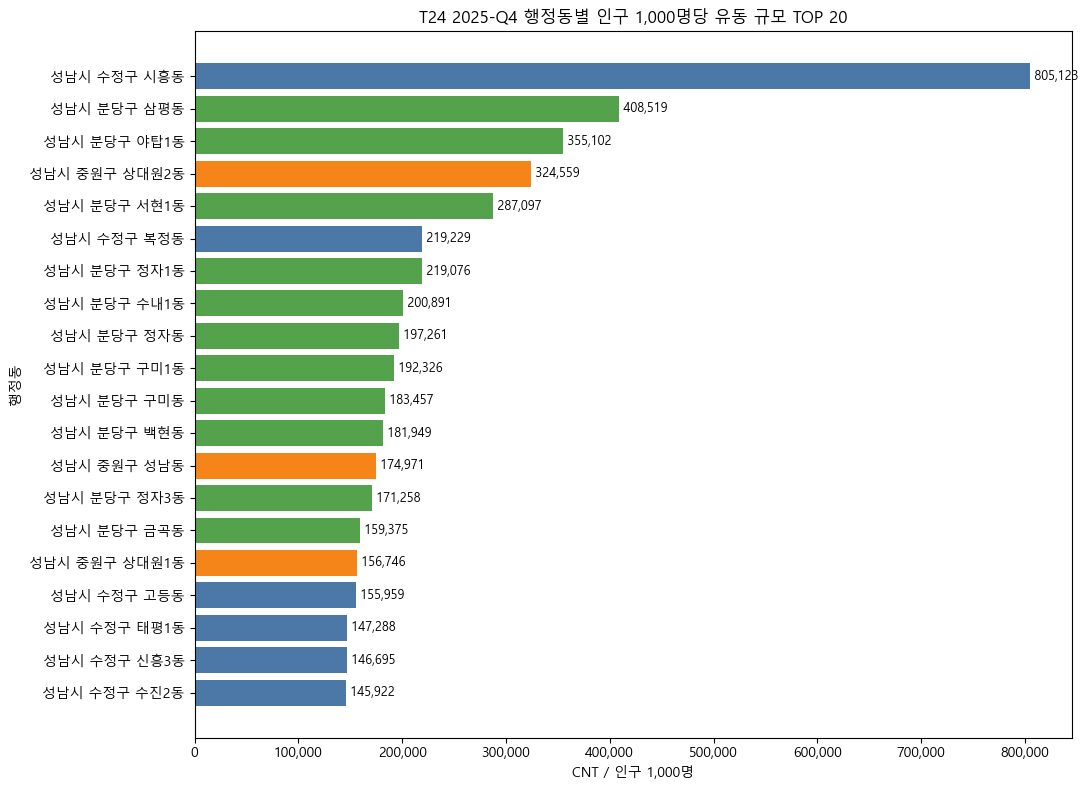

In [49]:
fig, ax = plt.subplots(figsize=(11, 8))
colors = {"성남시 수정구": "#4C78A8", "성남시 중원구": "#F58518", "성남시 분당구": "#54A24B"}
bar_colors = viz_top20["CTY_NM"].map(colors).fillna("#999999")

ax.barh(viz_top20["LABEL"][::-1], viz_top20["CNT_PER_1K_POP"][::-1], color=bar_colors[::-1])
ax.set_title(f"{focus_table_id} {viz_latest_quarter_label} 행정동별 인구 1,000명당 유동 규모 TOP 20")
ax.set_xlabel("CNT / 인구 1,000명")
ax.xaxis.set_major_formatter(number_formatter)
ax.set_ylabel("행정동")

for i, value in enumerate(viz_top20["CNT_PER_1K_POP"][::-1]):
    ax.text(value, i, f" {value:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

**그래프 설명 - 최근 분기 TOP 20**

최근 분기 기준으로 등록 인구 대비 T24 관측 규모가 큰 행정동을 보여준다. 값이 높은 지역은 거주 인구 대비 유동·활동 관측이 큰 지역 후보로 볼 수 있다.

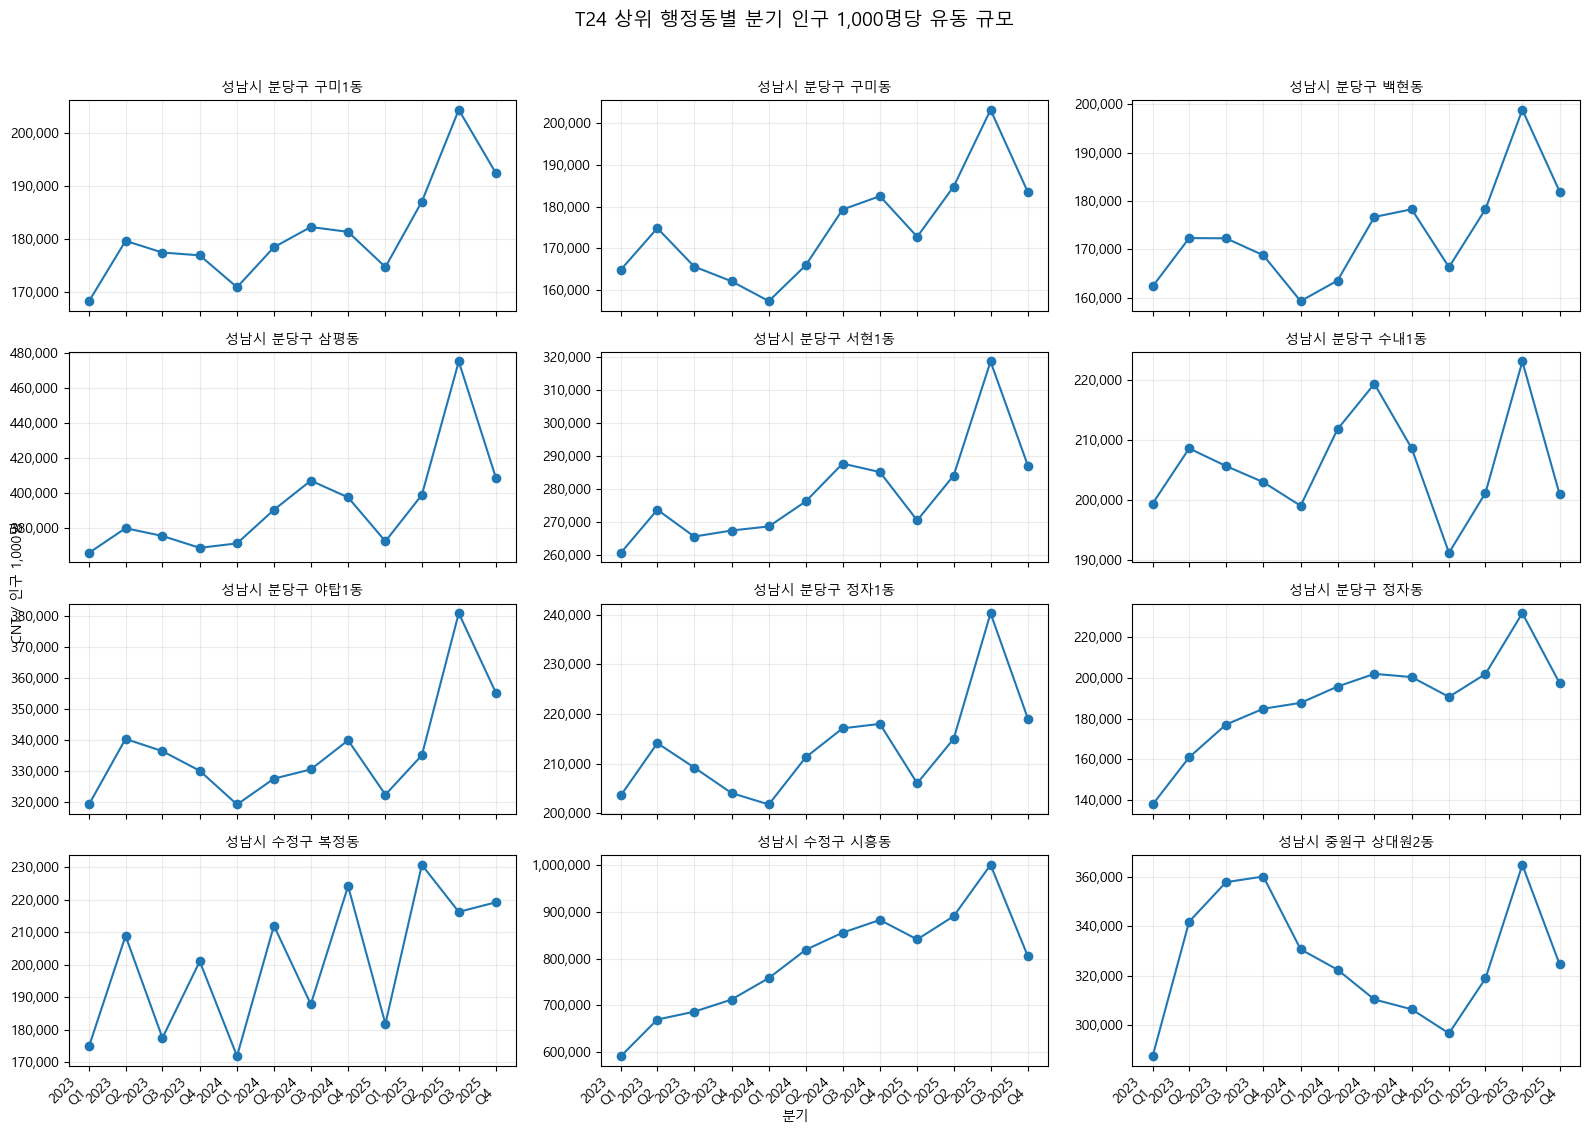

In [50]:
top12_codes = viz_top20["ADMI_CD"].head(12).tolist()
top12_trend = viz_df[viz_df["ADMI_CD"].isin(top12_codes)].copy()
top12_trend["LABEL"] = top12_trend["CTY_NM"] + " " + top12_trend["ADMI_NM"]

fig, axes = plt.subplots(4, 3, figsize=(16, 11), sharex=True)
axes = axes.ravel()

for ax, (label, sub) in zip(axes, top12_trend.groupby("LABEL")):
    sub = sub.sort_values("QUARTER_START")
    ax.plot(sub["QUARTER_START"], sub["CNT_PER_1K_POP"], marker="o", linewidth=1.5)
    ax.set_title(label, fontsize=10)
    ax.yaxis.set_major_formatter(number_formatter)
    ax.grid(alpha=0.25)
    ax.set_xticks(quarter_calendar_df["QUARTER_START"])
    ax.set_xticklabels(quarter_axis_labels, rotation=45, ha="right")

for ax in axes[len(top12_trend["LABEL"].unique()):]:
    ax.axis("off")

fig.suptitle(f"{focus_table_id} 상위 행정동별 분기 인구 1,000명당 유동 규모", y=1.02, fontsize=14)
fig.text(0.5, 0.01, "분기", ha="center")
fig.text(0.01, 0.5, "CNT / 인구 1,000명", va="center", rotation="vertical")
plt.tight_layout()
plt.show()

**그래프 설명 - 상위 행정동 분기 추세**

상위 행정동이 최근 분기에만 튄 것인지, 여러 분기 동안 계속 높은지 확인한다. 지속적으로 높으면 구조적 중심지 후보, 특정 분기만 높으면 이벤트나 계절 요인을 확인해야 한다.

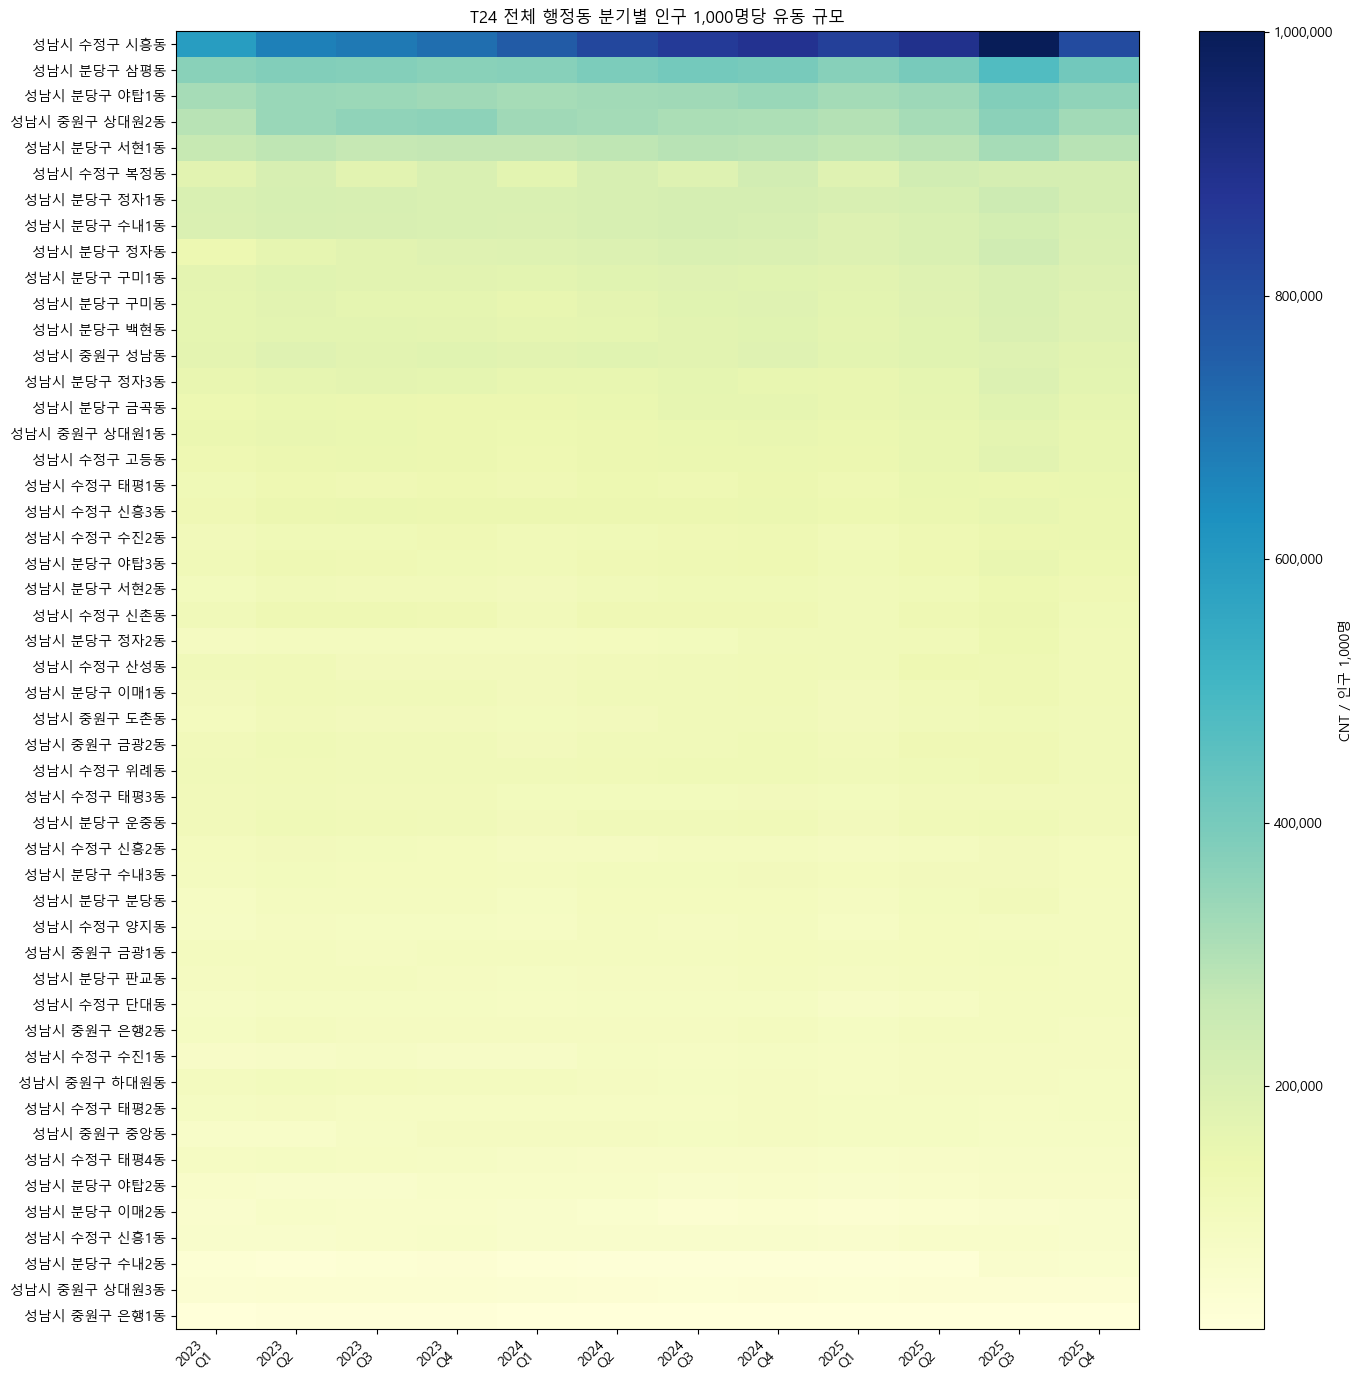

In [51]:
heatmap_all = viz_df.copy()
heatmap_all["LABEL"] = heatmap_all["CTY_NM"] + " " + heatmap_all["ADMI_NM"]

latest_order = (
    heatmap_all[heatmap_all["QUARTER_START"] == viz_latest_quarter]
    .sort_values("CNT_PER_1K_POP", ascending=False)["LABEL"]
    .tolist()
)

heatmap_all_pivot = heatmap_all.pivot(index="LABEL", columns="base_quarter", values="CNT_PER_1K_POP").reindex(columns=quarter_order)
heatmap_all_pivot = heatmap_all_pivot.loc[[x for x in latest_order if x in heatmap_all_pivot.index]]

fig_height = max(10, len(heatmap_all_pivot) * 0.28)
fig, ax = plt.subplots(figsize=(14, fig_height))
im = ax.imshow(heatmap_all_pivot.values, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(heatmap_all_pivot.columns)))
ax.set_xticklabels([quarter_label_map.get(col, col) for col in heatmap_all_pivot.columns], rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_all_pivot.index)))
ax.set_yticklabels(heatmap_all_pivot.index)
ax.set_title(f"{focus_table_id} 전체 행정동 분기별 인구 1,000명당 유동 규모")
cbar = fig.colorbar(im, ax=ax, label="CNT / 인구 1,000명")
cbar.ax.yaxis.set_major_formatter(number_formatter)
plt.tight_layout()
plt.show()

**그래프 설명 - 전체 행정동 분기 히트맵**

행은 행정동, 열은 분기다. 특정 행정동의 색이 계속 진하면 지속적 중심지, 특정 분기에 여러 행정동이 동시에 진해지면 공통 계절성이나 이벤트 가능성을 본다.

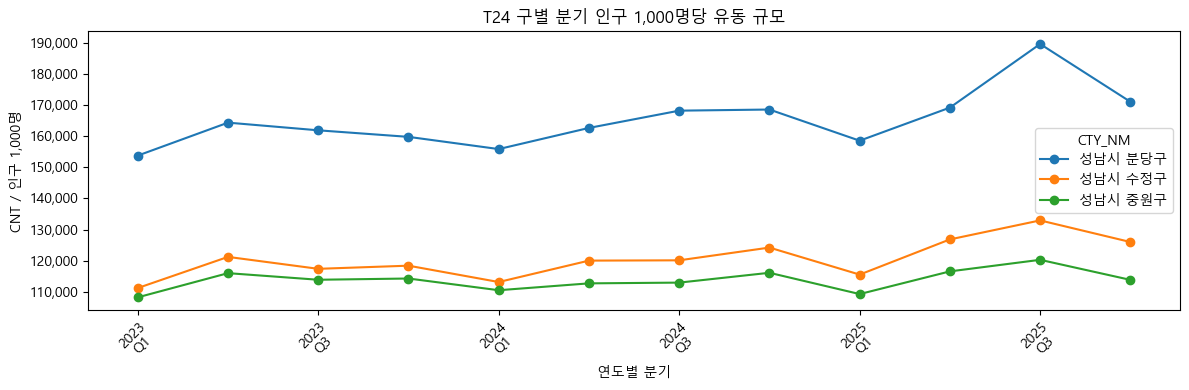

In [52]:
cty_quarterly_panel = (
    focus_quarterly_admin.groupby(["QUARTER_START", "base_quarter", "CTY_NM"], as_index=False)
    .agg(
        CNT_SUM=("CNT_SUM", "sum"),
        TOTAL_POP=("TOTAL_POP", "sum"),
        HOUSEHOLDS=("HOUSEHOLDS", "sum"),
    )
)
cty_quarterly_panel["CNT_PER_1K_POP"] = cty_quarterly_panel["CNT_SUM"] / cty_quarterly_panel["TOTAL_POP"] * 1000

cty_pivot = cty_quarterly_panel.pivot(index="QUARTER_START", columns="CTY_NM", values="CNT_PER_1K_POP")
cty_pivot = cty_pivot.reindex(quarter_calendar_df["QUARTER_START"])
cty_plot = cty_pivot.copy()
cty_plot.index = quarter_axis_labels
ax = cty_plot.plot(figsize=(12, 4), marker="o", title=f"{focus_table_id} 구별 분기 인구 1,000명당 유동 규모")
ax.set_xlabel("연도별 분기")
ax.tick_params(axis="x", rotation=45)
ax.set_ylabel("CNT / 인구 1,000명")
ax.yaxis.set_major_formatter(number_formatter)
plt.tight_layout()
plt.show()

**그래프 설명 - 구별 분기 추세**

행정동 결과를 구 단위로 묶어 큰 흐름을 보는 그래프다. 발표에서는 구 단위 흐름을 먼저 보여준 뒤, 행정동 TOP과 히트맵으로 내려가면 설명이 쉽다.

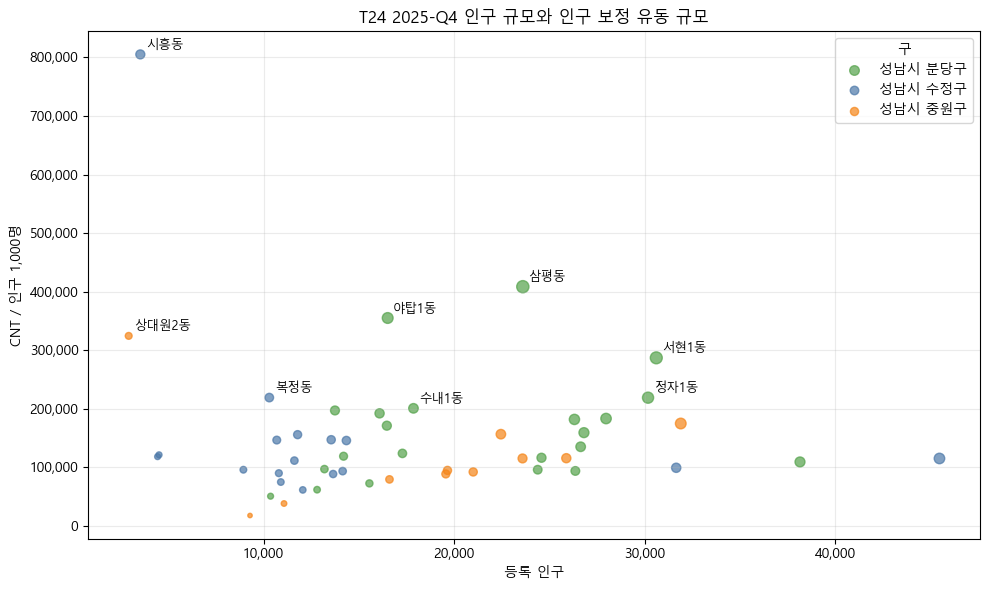

In [53]:
fig, ax = plt.subplots(figsize=(10, 6))

for cty_name, sub in viz_latest.groupby("CTY_NM"):
    ax.scatter(
        sub["TOTAL_POP"],
        sub["CNT_PER_1K_POP"],
        s=np.sqrt(sub["CNT_SUM"]) / 40,
        alpha=0.7,
        label=cty_name,
        color=colors.get(cty_name, None),
    )

label_df = viz_latest.sort_values("CNT_PER_1K_POP", ascending=False).head(8)
for _, row in label_df.iterrows():
    ax.annotate(row["ADMI_NM"], (row["TOTAL_POP"], row["CNT_PER_1K_POP"]), fontsize=9, xytext=(4, 4), textcoords="offset points")

ax.set_title(f"{focus_table_id} {viz_latest_quarter_label} 인구 규모와 인구 보정 유동 규모")
ax.set_xlabel("등록 인구")
ax.xaxis.set_major_formatter(number_formatter)
ax.set_ylabel("CNT / 인구 1,000명")
ax.yaxis.set_major_formatter(number_formatter)
ax.legend(title="구")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

**그래프 설명 - 인구 규모 vs 인구 보정 유동 규모**

x축은 등록 인구, y축은 인구 1,000명당 관측 규모다. 왼쪽 위는 거주 인구는 작지만 유동 강도가 큰 지역 후보로 볼 수 있다.

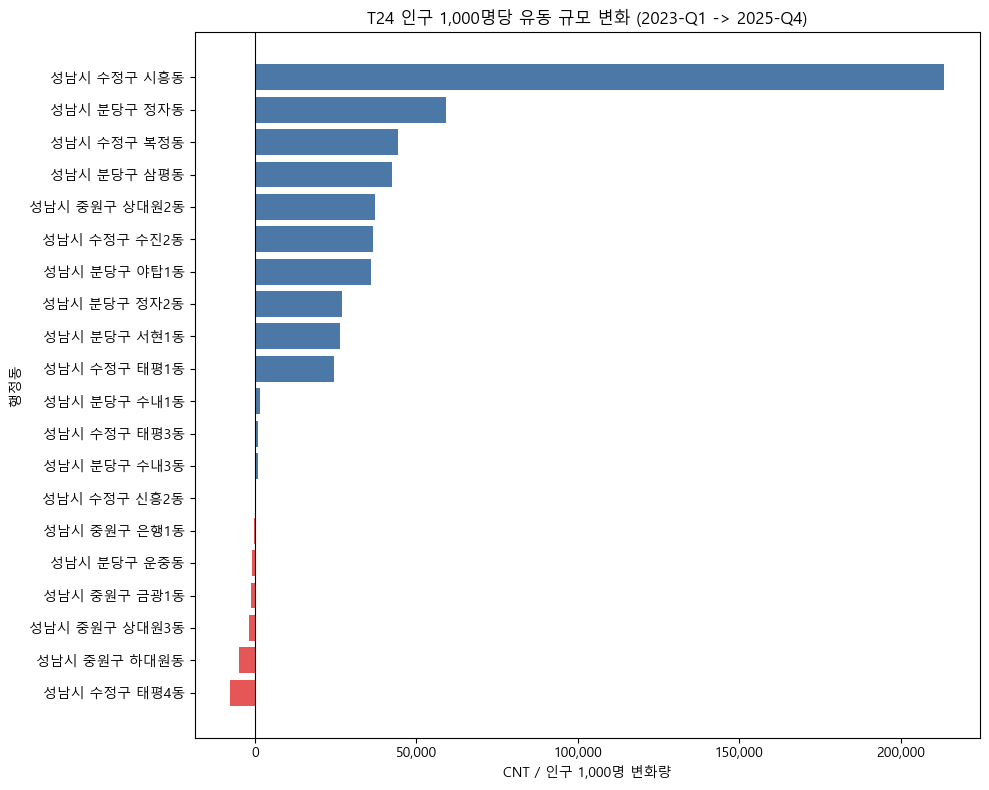

In [54]:
rank_first_quarter = viz_df["QUARTER_START"].min()
rank_latest_quarter = viz_df["QUARTER_START"].max()
rank_first_label = viz_df.loc[viz_df["QUARTER_START"] == rank_first_quarter, "base_quarter"].iloc[0]
rank_latest_label = viz_df.loc[viz_df["QUARTER_START"] == rank_latest_quarter, "base_quarter"].iloc[0]

rank_first = (
    viz_df[viz_df["QUARTER_START"] == rank_first_quarter]
    [["ADMI_CD", "CTY_NM", "ADMI_NM", "CNT_PER_1K_POP"]]
    .rename(columns={"CNT_PER_1K_POP": "FIRST_CNT_PER_1K_POP"})
)
rank_latest = (
    viz_df[viz_df["QUARTER_START"] == rank_latest_quarter]
    [["ADMI_CD", "CNT_PER_1K_POP"]]
    .rename(columns={"CNT_PER_1K_POP": "LATEST_CNT_PER_1K_POP"})
)

rank_change = rank_first.merge(rank_latest, on="ADMI_CD", how="inner")
rank_change["CHANGE"] = rank_change["LATEST_CNT_PER_1K_POP"] - rank_change["FIRST_CNT_PER_1K_POP"]
rank_change["LABEL"] = rank_change["CTY_NM"] + " " + rank_change["ADMI_NM"]

rank_change_plot = pd.concat(
    [
        rank_change.nlargest(10, "CHANGE").assign(TYPE="증가 TOP 10"),
        rank_change.nsmallest(10, "CHANGE").assign(TYPE="감소 TOP 10"),
    ]
).sort_values("CHANGE")

fig, ax = plt.subplots(figsize=(10, 8))
bar_colors = np.where(rank_change_plot["CHANGE"] >= 0, "#4C78A8", "#E45756")
ax.barh(rank_change_plot["LABEL"], rank_change_plot["CHANGE"], color=bar_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"{focus_table_id} 인구 1,000명당 유동 규모 변화 ({rank_first_label} -> {rank_latest_label})")
ax.set_xlabel("CNT / 인구 1,000명 변화량")
ax.xaxis.set_major_formatter(number_formatter)
ax.set_ylabel("행정동")
plt.tight_layout()
plt.show()

**그래프 설명 - 기간 전체 증가/감소 행정동**

첫 분기와 최근 분기의 인구 보정 유동 규모 차이를 보여준다. 단기 급변보다 분석 기간 전체에서 구조적으로 커졌거나 작아진 행정동을 찾는 용도다.

In [55]:
quarter_admin_outliers = (
    focus_quarterly_admin.dropna(subset=["CNT_PER_PERSON_QOQ_PCT"])
    .assign(ABS_QOQ_PCT=lambda df: df["CNT_PER_PERSON_QOQ_PCT"].abs())
    .sort_values("ABS_QOQ_PCT", ascending=False)
    .head(30)
)

quarter_admin_outliers[
    [
        "base_quarter", "CTY_NM", "ADMI_NM", "TOTAL_POP", "CNT_SUM",
        "CNT_PER_1K_POP", "CNT_PER_PERSON_QOQ_PCT"
    ]
]

,base_quarter,CTY_NM,ADMI_NM,TOTAL_POP,CNT_SUM,CNT_PER_1K_POP,CNT_PER_PERSON_QOQ_PCT
76,2025-Q3,성남시 분당구,수내2동,10404.000000,581398.39,55882.198193,0.855958
232,2025-Q2,성남시 수정구,복정동,10238.000000,2362315.34,230739.923813,0.269465
192,2024-Q2,성남시 수정구,복정동,10370.000000,2198483.68,212004.212150,0.233937
69,2024-Q1,성남시 분당구,수내2동,10396.000000,310057.68,29824.709504,-0.212302
563,2025-Q3,성남시 분당구,정자3동,16524.333333,3233097.65,195656.767797,0.206021
111,2025-Q4,성남시 수정구,시흥동,3533.666667,2845036.36,805123.014810,-0.195260
389,2023-Q2,성남시 수정구,복정동,10611.666667,2216297.53,208854.801005,0.194265
424,2024-Q4,성남시 수정구,복정동,10212.666667,2289583.90,224190.603173,0.193731
302,2025-Q3,성남시 분당구,삼평동,23614.666667,11222106.41,475217.650471,0.190828
24,2023-Q2,성남시 중원구,상대원2동,3496.000000,1195434.90,341943.621281,0.190397


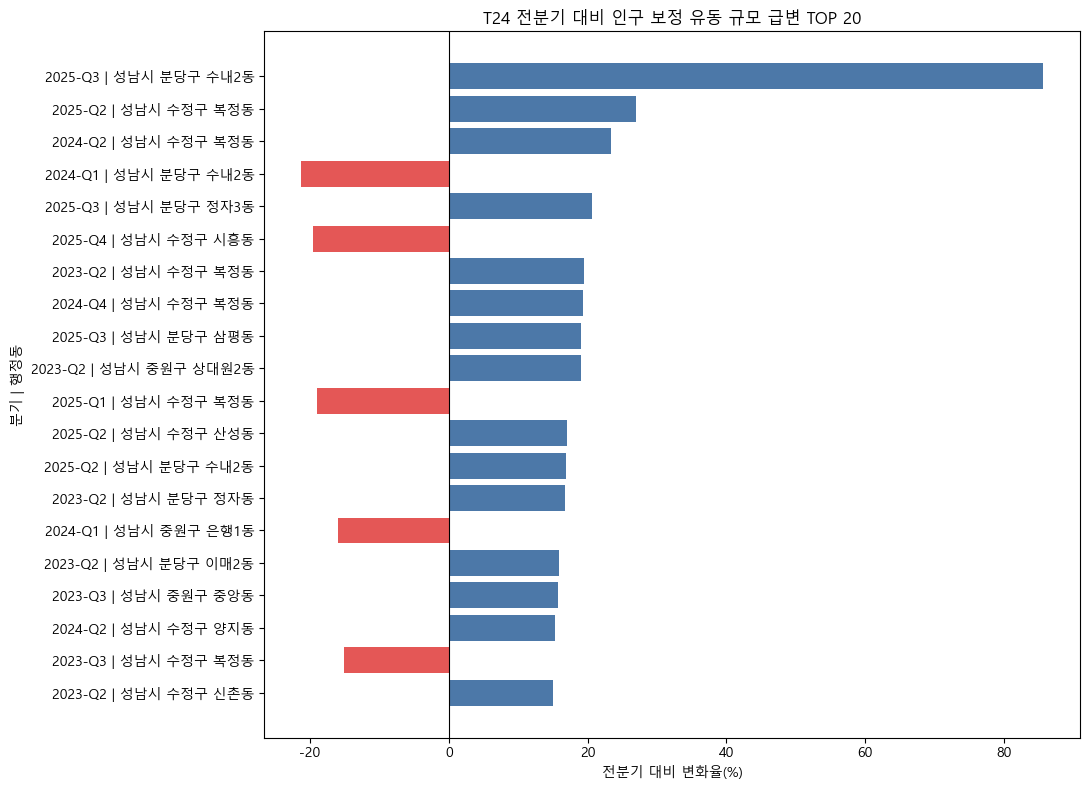

In [56]:
outlier_plot = quarter_admin_outliers.head(20).copy()
outlier_plot["LABEL"] = outlier_plot["base_quarter"] + " | " + outlier_plot["CTY_NM"] + " " + outlier_plot["ADMI_NM"]

fig, ax = plt.subplots(figsize=(11, 8))
bar_colors = np.where(outlier_plot["CNT_PER_PERSON_QOQ_PCT"] >= 0, "#4C78A8", "#E45756")
ax.barh(outlier_plot["LABEL"][::-1], (outlier_plot["CNT_PER_PERSON_QOQ_PCT"] * 100)[::-1], color=bar_colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"{focus_table_id} 전분기 대비 인구 보정 유동 규모 급변 TOP 20")
ax.set_xlabel("전분기 대비 변화율(%)")
ax.set_ylabel("분기 | 행정동")
plt.tight_layout()
plt.show()

**그래프 설명 - 전분기 대비 급증/급감 TOP 20**

전분기 대비 변화율이 큰 행정동·분기를 보여준다. 원인 분석 후보를 좁히는 용도이며, 실제 해석에서는 계절성, 행사, 데이터 누락 가능성을 같이 확인해야 한다.

## PURPOSE / TRANS_GB 코드 정의

성남시 제공 코드 정의는 아래와 같이 반영한다. 단, 성남시에 문의한 내용처럼 이 값은 통신사가 위치 반경과 이동 패턴으로 추정한 값이므로 **실제 목적/실제 이동수단으로 단정하지 않고 보조지표로만 사용**한다.

In [57]:
PURPOSE_KO = {
    "0": "귀가",
    "1": "출근",
    "2": "등교",
    "3": "쇼핑",
    "4": "관광",
    "5": "병원",
    "6": "기타",
}

PURPOSE_VAR = {
    "0": "home_return",
    "1": "commute",
    "2": "school",
    "3": "shopping",
    "4": "tourism",
    "5": "hospital",
    "6": "other",
}

TRANS_KO = {
    "0": "차량",
    "1": "노선버스",
    "2": "지하철",
    "3": "도보",
    "4": "고속버스",
    "5": "기차",
    "6": "항공",
    "7": "기타",
}

TRANS_VAR = {
    "0": "car",
    "1": "bus",
    "2": "subway",
    "3": "walk",
    "4": "express_bus",
    "5": "train",
    "6": "air",
    "7": "other",
}

code_definition = pd.DataFrame(
    [{"column": "PURPOSE", "code": int(k), "meaning": v, "status": "코드값 정의 확인 / 값 자체는 통신 추정"} for k, v in PURPOSE_KO.items()]
    + [{"column": "TRANS_GB", "code": int(k), "meaning": v, "status": "코드값 정의 확인 / 값 자체는 통신 추정"} for k, v in TRANS_KO.items()]
)

code_definition

,column,code,meaning,status
0,PURPOSE,0,귀가,코드값 정의 확인 / 값 자체는 통신 추정
1,PURPOSE,1,출근,코드값 정의 확인 / 값 자체는 통신 추정
2,PURPOSE,2,등교,코드값 정의 확인 / 값 자체는 통신 추정
3,PURPOSE,3,쇼핑,코드값 정의 확인 / 값 자체는 통신 추정
4,PURPOSE,4,관광,코드값 정의 확인 / 값 자체는 통신 추정
5,PURPOSE,5,병원,코드값 정의 확인 / 값 자체는 통신 추정
6,PURPOSE,6,기타,코드값 정의 확인 / 값 자체는 통신 추정
7,TRANS_GB,0,차량,코드값 정의 확인 / 값 자체는 통신 추정
8,TRANS_GB,1,노선버스,코드값 정의 확인 / 값 자체는 통신 추정
9,TRANS_GB,2,지하철,코드값 정의 확인 / 값 자체는 통신 추정


## T24 분기별 이동목적 보조지표

`T24`에는 `PURPOSE`가 있으므로 최근 분기 상위 행정동의 목적 구성비를 본다. 쇼핑·관광·병원 같은 목적은 상권/방문 성격을 설명하는 보조지표 후보가 될 수 있다.

In [58]:
t24_latest_quarter = viz_latest_quarter
t24_latest_quarter_label = viz_latest_quarter_label
t24_top10_codes = viz_top20["ADMI_CD"].head(10).astype(int).tolist()
t24_top10_codes_sql = ", ".join(map(str, t24_top10_codes))

t24_latest_population_for_viz = (
    population_quarterly[population_quarterly["QUARTER_START"] == t24_latest_quarter]
    [["ADMI_CD", "CTY_NM", "ADMI_NM"]]
)

t24_latest_purpose = q(f'''
    SELECT
        CAST(ADMI_CD AS BIGINT) AS ADMI_CD,
        CAST(PURPOSE AS VARCHAR) AS PURPOSE_CODE,
        SUM(CNT) AS CNT_SUM
    FROM {scan_sql("T24")}
    WHERE {quarter_start_expr(t24_d)} = DATE '{t24_latest_quarter:%Y-%m-%d}'
      AND ADMI_CD IN ({t24_top10_codes_sql})
    GROUP BY 1, 2
''')

t24_latest_purpose = t24_latest_purpose.merge(t24_latest_population_for_viz, on="ADMI_CD", how="left")
t24_latest_purpose["LABEL"] = t24_latest_purpose["CTY_NM"] + " " + t24_latest_purpose["ADMI_NM"]
t24_latest_purpose["PURPOSE_NAME"] = t24_latest_purpose["PURPOSE_CODE"].map(PURPOSE_KO).fillna("미확인")
t24_latest_purpose["PURPOSE_VAR"] = t24_latest_purpose["PURPOSE_CODE"].map(PURPOSE_VAR).fillna("unknown")
t24_latest_purpose["PURPOSE_SHARE"] = (
    t24_latest_purpose["CNT_SUM"] / t24_latest_purpose.groupby("ADMI_CD")["CNT_SUM"].transform("sum")
)

t24_latest_purpose.head()

,ADMI_CD,PURPOSE_CODE,CNT_SUM,CTY_NM,ADMI_NM,LABEL,PURPOSE_NAME,PURPOSE_VAR,PURPOSE_SHARE
0,41133580,6,391928.99,성남시 중원구,상대원2동,성남시 중원구 상대원2동,기타,other,0.413081
1,41135520,1,740610.52,성남시 분당구,수내1동,성남시 분당구 수내1동,출근,commute,0.206298
2,41135550,1,1387320.94,성남시 분당구,정자1동,성남시 분당구 정자1동,출근,commute,0.209811
3,41135620,1,1047399.68,성남시 분당구,야탑1동,성남시 분당구 야탑1동,출근,commute,0.178574
4,41135655,2,124116.70,성남시 분당구,삼평동,성남시 분당구 삼평동,등교,school,0.012869


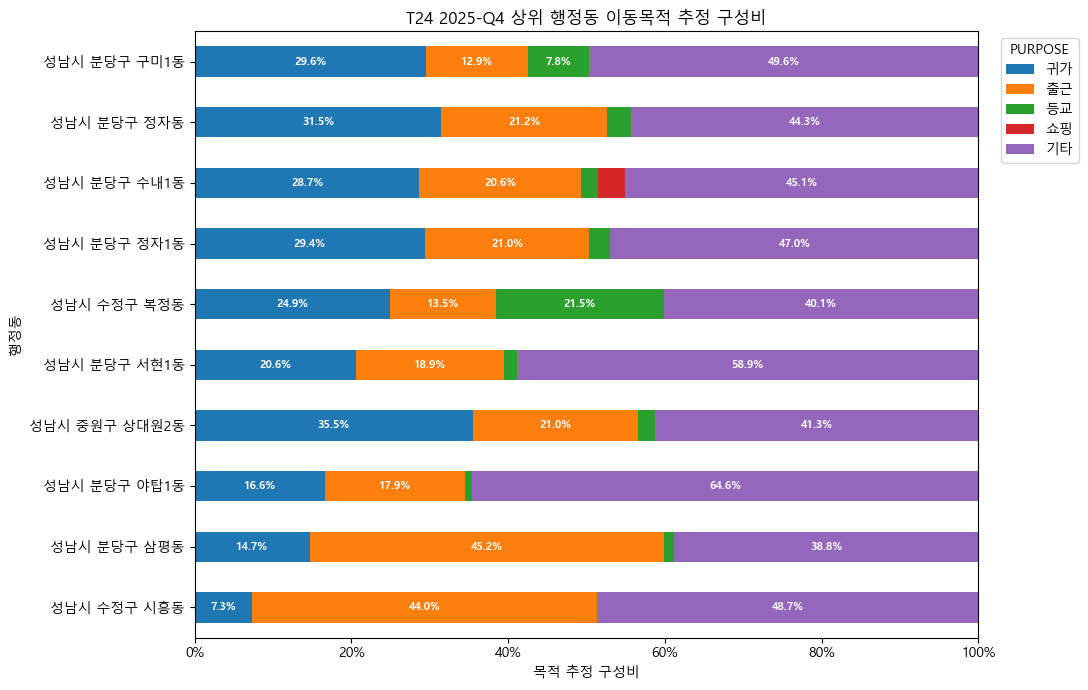

In [59]:
purpose_order = ["귀가", "출근", "등교", "쇼핑", "관광", "병원", "기타", "미확인"]
purpose_stack = (
    t24_latest_purpose.pivot_table(index="LABEL", columns="PURPOSE_NAME", values="PURPOSE_SHARE", aggfunc="sum", fill_value=0)
    .reindex(columns=[c for c in purpose_order if c in t24_latest_purpose["PURPOSE_NAME"].unique()], fill_value=0)
)
purpose_stack = purpose_stack.loc[viz_top20.head(10)["LABEL"]]

ax = purpose_stack.plot(
    kind="barh",
    stacked=True,
    figsize=(11, 7),
    title=f"T24 {t24_latest_quarter_label} 상위 행정동 이동목적 추정 구성비",
)
ax.set_xlabel("목적 추정 구성비")
ax.xaxis.set_major_formatter(ratio_formatter)
ax.set_xlim(0, 1)
ax.set_ylabel("행정동")

for container in ax.containers:
    labels = [f"{bar.get_width():.1%}" if bar.get_width() >= 0.05 else "" for bar in container]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8, color="white", fontweight="bold")

ax.legend(title="PURPOSE", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**그래프 설명 - 상위 행정동 이동목적 추정 구성비**(정확한건 아님)

상위 행정동의 유동 규모가 어떤 추정 목적에서 나오는지 본다. 막대 안 숫자는 각 행정동 전체 `CNT` 중 해당 목적이 차지하는 비율이다. 예를 들어 쇼핑·관광 비중이 높은 행정동은 방문/상권 성격 보조지표로 볼 수 있다. 다만 목적은 통신 추정값이므로 모델의 보조 변수로만 사용한다.

In [60]:
t24_purpose_feature_candidate = (
    t24_latest_purpose.pivot_table(index=["ADMI_CD", "CTY_NM", "ADMI_NM"], columns="PURPOSE_VAR", values="PURPOSE_SHARE", aggfunc="sum", fill_value=0)
    .reset_index()
)

for col in ["shopping", "tourism", "hospital", "commute", "school", "home_return", "other"]:
    if col not in t24_purpose_feature_candidate.columns:
        t24_purpose_feature_candidate[col] = 0.0

t24_purpose_feature_candidate["q_shopping_visit_ratio_est"] = t24_purpose_feature_candidate["shopping"]
t24_purpose_feature_candidate["q_tourism_visit_ratio_est"] = t24_purpose_feature_candidate["tourism"]
t24_purpose_feature_candidate["q_commercial_purpose_ratio_est"] = (
    t24_purpose_feature_candidate["shopping"] + t24_purpose_feature_candidate["tourism"]
)
t24_purpose_feature_candidate["q_life_purpose_ratio_est"] = (
    t24_purpose_feature_candidate["home_return"] + t24_purpose_feature_candidate["commute"] + t24_purpose_feature_candidate["school"]
)

t24_purpose_feature_candidate[
    [
        "ADMI_CD", "CTY_NM", "ADMI_NM",
        "q_shopping_visit_ratio_est", "q_tourism_visit_ratio_est",
        "q_commercial_purpose_ratio_est", "q_life_purpose_ratio_est",
    ]
].sort_values("q_commercial_purpose_ratio_est", ascending=False)

PURPOSE_VAR,ADMI_CD,CTY_NM,ADMI_NM,q_shopping_visit_ratio_est,q_tourism_visit_ratio_est,q_commercial_purpose_ratio_est,q_life_purpose_ratio_est
3,41135520,성남시 분당구,수내1동,0.034951,0.0,0.034951,0.514365
0,41131620,성남시 수정구,복정동,0.000000,0.0,0.000000,0.598703
1,41131650,성남시 수정구,시흥동,0.000000,0.0,0.000000,0.513264
2,41133580,성남시 중원구,상대원2동,0.000000,0.0,0.000000,0.586919
4,41135545,성남시 분당구,정자동,0.000000,0.0,0.000000,0.557190
5,41135550,성남시 분당구,정자1동,0.000000,0.0,0.000000,0.530298
6,41135580,성남시 분당구,서현1동,0.000000,0.0,0.000000,0.411369
7,41135620,성남시 분당구,야탑1동,0.000000,0.0,0.000000,0.354394
8,41135655,성남시 분당구,삼평동,0.000000,0.0,0.000000,0.611643
9,41135665,성남시 분당구,구미1동,0.000000,0.0,0.000000,0.503558


## T26 분기별 이동수단 + 체류 보조지표

`T26`은 도착 행정동 기준으로 `PURPOSE`, `TRANS_GB`, `DURATION`이 함께 들어 있다. 따라서 최근 분기 상위 행정동에 대해 이동수단 구성비와 체류시간 보조지표를 만든다.

기본은 `T24` 상위 10개 행정동에 대해서만 `T26`을 조회한다. 전체 행정동·전체 분기 집계가 필요하면 별도 산출 노트북에서 돌리는 편이 좋다.

In [61]:
if RUN_T26_TRANSPORT_AUXILIARY_EDA:
    t26_d = date_expr("T26")
    t26_latest_aux = q(f'''
        SELECT
            CAST(D_ADMI_CD AS BIGINT) AS ADMI_CD,
            CAST(PURPOSE AS VARCHAR) AS PURPOSE_CODE,
            CAST(TRANS_GB AS VARCHAR) AS TRANS_CODE,
            SUM(CNT) AS CNT_SUM,
            SUM(DURATION * CNT) AS DURATION_WEIGHTED_SUM
        FROM {scan_sql("T26")}
        WHERE {quarter_start_expr(t26_d)} = DATE '{t24_latest_quarter:%Y-%m-%d}'
          AND D_ADMI_CD IN ({t24_top10_codes_sql})
        GROUP BY 1, 2, 3
    ''')

    t26_latest_aux = t26_latest_aux.merge(t24_latest_population_for_viz, on="ADMI_CD", how="left")
    t26_latest_aux["LABEL"] = t26_latest_aux["CTY_NM"] + " " + t26_latest_aux["ADMI_NM"]
    t26_latest_aux["PURPOSE_NAME"] = t26_latest_aux["PURPOSE_CODE"].map(PURPOSE_KO).fillna("미확인")
    t26_latest_aux["TRANS_NAME"] = t26_latest_aux["TRANS_CODE"].map(TRANS_KO).fillna("미확인")
else:
    t26_latest_aux = pd.DataFrame(
        {"안내": ["T26 이동수단 보조지표는 RUN_T26_TRANSPORT_AUXILIARY_EDA=True일 때 실행됩니다."]}
    )

t26_latest_aux.head()

,ADMI_CD,PURPOSE_CODE,TRANS_CODE,CNT_SUM,DURATION_WEIGHTED_SUM,CTY_NM,ADMI_NM,LABEL,PURPOSE_NAME,TRANS_NAME
0,41131620,0,7,61633.74,18218522.7,성남시 수정구,복정동,성남시 수정구 복정동,귀가,기타
1,41135520,0,2,110758.26,28757943.9,성남시 분당구,수내1동,성남시 분당구 수내1동,귀가,지하철
2,41135550,0,7,208419.25,53415583.2,성남시 분당구,정자1동,성남시 분당구 정자1동,귀가,기타
3,41135620,6,1,628362.71,77361375.9,성남시 분당구,야탑1동,성남시 분당구 야탑1동,기타,노선버스
4,41135655,1,1,639119.21,276224917.5,성남시 분당구,삼평동,성남시 분당구 삼평동,출근,노선버스


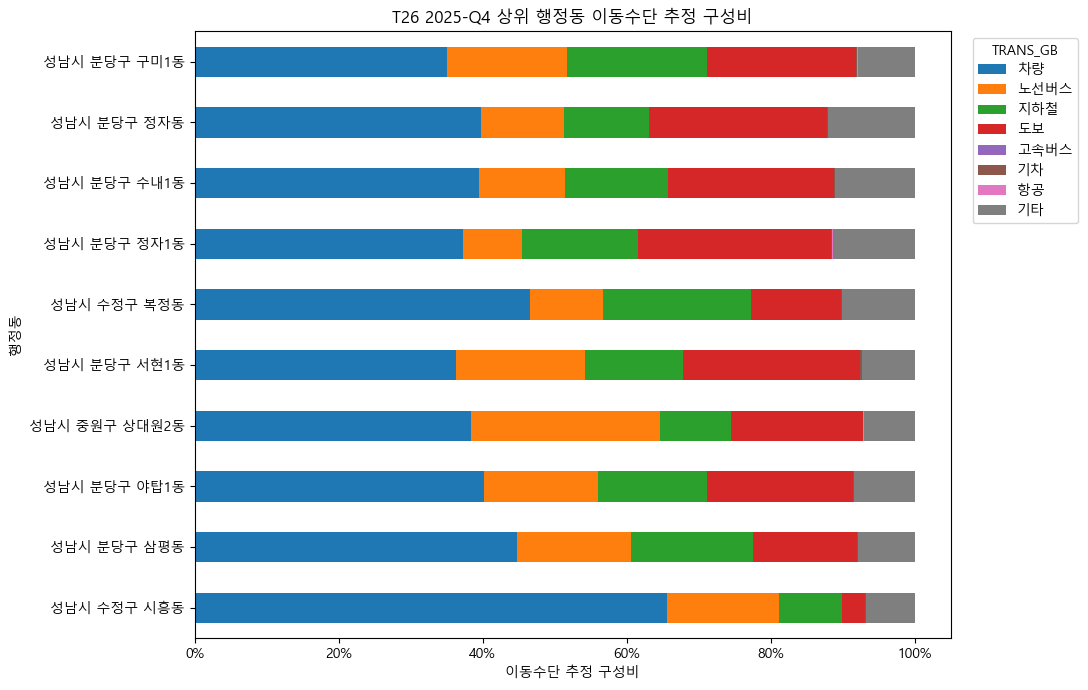

In [62]:
if RUN_T26_TRANSPORT_AUXILIARY_EDA and not t26_latest_aux.empty:
    t26_transport_stack_raw = (
        t26_latest_aux.groupby(["ADMI_CD", "LABEL", "TRANS_NAME"], as_index=False)["CNT_SUM"].sum()
    )
    t26_transport_stack_raw["TRANS_SHARE"] = (
        t26_transport_stack_raw["CNT_SUM"]
        / t26_transport_stack_raw.groupby("ADMI_CD")["CNT_SUM"].transform("sum")
    )

    trans_order = ["차량", "노선버스", "지하철", "도보", "고속버스", "기차", "항공", "기타", "미확인"]
    transport_stack = (
        t26_transport_stack_raw.pivot_table(index="LABEL", columns="TRANS_NAME", values="TRANS_SHARE", aggfunc="sum", fill_value=0)
        .reindex(columns=[c for c in trans_order if c in t26_transport_stack_raw["TRANS_NAME"].unique()], fill_value=0)
    )
    transport_stack = transport_stack.loc[viz_top20.head(10)["LABEL"]]

    ax = transport_stack.plot(
        kind="barh",
        stacked=True,
        figsize=(11, 7),
        title=f"T26 {t24_latest_quarter_label} 상위 행정동 이동수단 추정 구성비",
    )
    ax.set_xlabel("이동수단 추정 구성비")
    ax.xaxis.set_major_formatter(ratio_formatter)
    ax.set_ylabel("행정동")
    ax.legend(title="TRANS_GB", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    pd.DataFrame({"안내": ["T26 이동수단 그래프는 RUN_T26_TRANSPORT_AUXILIARY_EDA=True일 때 표시됩니다."]})

**그래프 설명 - 상위 행정동 이동수단 추정 구성비**

상위 행정동의 유동이 차량, 버스, 지하철, 도보 중 어디에 가까운지 보는 보조 그래프다. 접근성이나 교통 의존성 변수 후보를 만들 때 사용한다.(추정값이라 정확한건 아님)

In [63]:
if RUN_T26_TRANSPORT_AUXILIARY_EDA and not t26_latest_aux.empty:
    t26_aux_total = (
        t26_latest_aux.groupby(["ADMI_CD", "CTY_NM", "ADMI_NM", "LABEL"], as_index=False)
        .agg(
            total_cnt=("CNT_SUM", "sum"),
            duration_weighted_sum=("DURATION_WEIGHTED_SUM", "sum"),
        )
    )
    t26_aux_total["q_avg_stay_time_est"] = t26_aux_total["duration_weighted_sum"] / t26_aux_total["total_cnt"]

    transport_share = (
        t26_latest_aux.groupby(["ADMI_CD", "TRANS_CODE"], as_index=False)["CNT_SUM"].sum()
    )
    transport_share["share"] = transport_share["CNT_SUM"] / transport_share.groupby("ADMI_CD")["CNT_SUM"].transform("sum")
    transport_share_wide = transport_share.pivot(index="ADMI_CD", columns="TRANS_CODE", values="share").fillna(0)

    purpose_share = (
        t26_latest_aux.groupby(["ADMI_CD", "PURPOSE_CODE"], as_index=False)["CNT_SUM"].sum()
    )
    purpose_share["share"] = purpose_share["CNT_SUM"] / purpose_share.groupby("ADMI_CD")["CNT_SUM"].transform("sum")
    purpose_share_wide = purpose_share.pivot(index="ADMI_CD", columns="PURPOSE_CODE", values="share").fillna(0)

    t26_aux_feature_candidate = t26_aux_total[["ADMI_CD", "CTY_NM", "ADMI_NM", "q_avg_stay_time_est"]].copy()
    t26_aux_feature_candidate["q_public_transport_ratio_est"] = (
        transport_share_wide.get("1", 0) + transport_share_wide.get("2", 0)
    ).reindex(t26_aux_feature_candidate["ADMI_CD"]).to_numpy()
    t26_aux_feature_candidate["q_car_ratio_est"] = (
        transport_share_wide.get("0", 0).reindex(t26_aux_feature_candidate["ADMI_CD"]).to_numpy()
        if "0" in transport_share_wide.columns else 0
    )
    t26_aux_feature_candidate["q_walk_ratio_est"] = (
        transport_share_wide.get("3", 0).reindex(t26_aux_feature_candidate["ADMI_CD"]).to_numpy()
        if "3" in transport_share_wide.columns else 0
    )
    t26_aux_feature_candidate["q_shopping_tourism_ratio_est"] = (
        purpose_share_wide.get("3", 0) + purpose_share_wide.get("4", 0)
    ).reindex(t26_aux_feature_candidate["ADMI_CD"]).to_numpy()

    t26_aux_feature_candidate.sort_values("q_public_transport_ratio_est", ascending=False)
else:
    t26_aux_feature_candidate = pd.DataFrame(
        {"안내": ["T26 보조 변수 후보표는 RUN_T26_TRANSPORT_AUXILIARY_EDA=True일 때 생성됩니다."]}
    )
    t26_aux_feature_candidate

## 더 뚜렷한 신호 지표 추가 EDA

앞의 그래프는 분기별 유동 규모를 보는 기본 EDA다. 여기서는 모델링 후보로 더 선명하게 쓰기 좋은 지표를 추가한다.

단순 `CNT_SUM`은 인구가 많은 행정동이 크게 보일 수 있으므로, 아래 지표처럼 **비교 기준이 있는 값**을 우선한다.

| 지표 방향 | 왜 추가하는가 |
|---|---|
| 성남시 평균 대비 지수 | 같은 분기 성남시 평균보다 얼마나 강한지 바로 비교 가능 |
| 전년동분기 변화율 | 계절성을 줄이고 구조적 증가/감소를 보기 좋음 |
| 주말/시간대 비중 | 상권·여가형 활동인지, 출근/생활형 활동인지 구분 가능 |
| 목적 집중도 | 특정 목적에 쏠린 지역인지, 여러 목적이 섞인 지역인지 확인 가능 |
| T22 성·연령·외국인 비중 | T24보다 연령대 컬럼이 명확해서 이용자 구성 지표로 쓰기 좋음 |
| T13 OD 유입/유출 | 실제 행정동 간 이동 구조를 볼 수 있으나 파일이 커서 옵션으로 관리 |

### 다른 T 데이터 활용 판단

다른 T 데이터도 모두 무조건 넣기보다, 분기·행정동 모델 키에 맞고 해석이 겹치지 않는 것을 우선한다.

| 테이블 | 활용 여부 | 이유 |
|---|---|---|
| `T24` | 기본 사용 | 행정동 단위, 목적·시간대가 있어 유동 규모와 활동 시간대를 보기 좋음 |
| `T22` | 추가 사용 | 성별·연령대 컬럼이 명확해서 이용자 구성 지표를 만들기 좋음 |
| `T26` | 이미 사용 | 도착 행정동 기준 체류시간, 이동목적, 이동수단을 같이 볼 수 있음 |
| `T13` | 옵션 사용 | 행정동 OD 유입·유출을 직접 볼 수 있지만 파일이 커서 필요 시 실행 |
| `T27` | 보조 후보 | 출발 행정동 기준 체류·수단 지표라 T26과 방향만 다름. 출발지 분석이 필요할 때 추가 |
| `T7`, `T11` | 보조 후보 | 도착/출발 이동수단만 볼 때 유용하지만 T26/T27과 일부 중복 |
| `T25` | 보조 후보 | 시군구 OD라 행정동 마스터 키와 바로 맞지 않아 구 단위 압력 지표로만 사용 |

이번 노트북에는 기본 실행이 가능한 `T24`, `T22`, `T26`을 중심으로 넣고, 대용량 OD인 `T13`은 옵션 셀로 둔다.

### T24 추가 신호 지표

`T24`에서 같은 분기·행정동 기준으로 주말, 목적, 성별, 시간대 지표를 추가한다.

`AGE_GRP`는 `01`과 `1`처럼 표기가 섞여 있어 이 섹션에서는 연령 해석에 쓰지 않고, 연령대 지표는 아래 `T22`에서 만든다.

In [64]:
t24_signal_raw = q(f'''
    SELECT
        {quarter_start_expr(t24_d)} AS QUARTER_START,
        {quarter_label_expr(t24_d)} AS base_quarter,
        CAST(ADMI_CD AS BIGINT) AS ADMI_CD,
        SUM(CNT) AS DETAIL_CNT_SUM,
        SUM(CASE WHEN EXTRACT(dow FROM CAST(ETL_YMD AS DATE)) IN (0, 6) THEN CNT ELSE 0 END) AS WEEKEND_CNT,
        SUM(CASE WHEN EXTRACT(dow FROM CAST(ETL_YMD AS DATE)) NOT IN (0, 6) THEN CNT ELSE 0 END) AS WEEKDAY_CNT,
        SUM(CASE WHEN TRY_CAST(TIME_CD AS INTEGER) BETWEEN 0 AND 5 THEN CNT ELSE 0 END) AS NIGHT_CNT_DETAIL,
        SUM(CASE WHEN TRY_CAST(TIME_CD AS INTEGER) BETWEEN 6 AND 10 THEN CNT ELSE 0 END) AS MORNING_CNT,
        SUM(CASE WHEN TRY_CAST(TIME_CD AS INTEGER) BETWEEN 11 AND 14 THEN CNT ELSE 0 END) AS LUNCH_CNT_DETAIL,
        SUM(CASE WHEN TRY_CAST(TIME_CD AS INTEGER) BETWEEN 17 AND 21 THEN CNT ELSE 0 END) AS EVENING_CNT_DETAIL,
        SUM(CASE WHEN PURPOSE = 0 THEN CNT ELSE 0 END) AS PURPOSE_HOME_CNT,
        SUM(CASE WHEN PURPOSE = 1 THEN CNT ELSE 0 END) AS PURPOSE_COMMUTE_CNT,
        SUM(CASE WHEN PURPOSE = 2 THEN CNT ELSE 0 END) AS PURPOSE_SCHOOL_CNT,
        SUM(CASE WHEN PURPOSE = 3 THEN CNT ELSE 0 END) AS PURPOSE_SHOPPING_CNT,
        SUM(CASE WHEN PURPOSE = 4 THEN CNT ELSE 0 END) AS PURPOSE_TOURISM_CNT,
        SUM(CASE WHEN PURPOSE = 5 THEN CNT ELSE 0 END) AS PURPOSE_HOSPITAL_CNT,
        SUM(CASE WHEN PURPOSE = 6 THEN CNT ELSE 0 END) AS PURPOSE_OTHER_CNT,
        SUM(CASE WHEN SEX_CD = 'M' THEN CNT ELSE 0 END) AS MALE_CNT,
        SUM(CASE WHEN SEX_CD = 'F' THEN CNT ELSE 0 END) AS FEMALE_CNT,
        SUM(CASE WHEN SEX_CD NOT IN ('M', 'F') OR SEX_CD IS NULL THEN CNT ELSE 0 END) AS UNKNOWN_SEX_CNT
    FROM {scan_sql("T24")}
    WHERE ADMI_CD IS NOT NULL
    GROUP BY 1, 2, 3
''')

t24_signal_panel = t24_quarterly_admin_panel.merge(
    t24_signal_raw,
    on=["QUARTER_START", "base_quarter", "ADMI_CD"],
    how="left",
)

ratio_cols = {
    "q_weekend_ratio": "WEEKEND_CNT",
    "q_weekday_ratio": "WEEKDAY_CNT",
    "q_morning_ratio": "MORNING_CNT",
    "q_night_ratio_detail": "NIGHT_CNT_DETAIL",
    "q_lunch_ratio_detail": "LUNCH_CNT_DETAIL",
    "q_evening_ratio_detail": "EVENING_CNT_DETAIL",
    "q_home_return_ratio_est": "PURPOSE_HOME_CNT",
    "q_commute_ratio_est": "PURPOSE_COMMUTE_CNT",
    "q_school_ratio_est": "PURPOSE_SCHOOL_CNT",
    "q_shopping_ratio_est": "PURPOSE_SHOPPING_CNT",
    "q_tourism_ratio_est": "PURPOSE_TOURISM_CNT",
    "q_hospital_ratio_est": "PURPOSE_HOSPITAL_CNT",
    "q_other_purpose_ratio_est": "PURPOSE_OTHER_CNT",
    "q_male_ratio_est": "MALE_CNT",
    "q_female_ratio_est": "FEMALE_CNT",
    "q_unknown_sex_ratio_est": "UNKNOWN_SEX_CNT",
}

for new_col, raw_col in ratio_cols.items():
    t24_signal_panel[new_col] = t24_signal_panel[raw_col] / t24_signal_panel["CNT_SUM"]

purpose_ratio_cols = [
    "q_home_return_ratio_est",
    "q_commute_ratio_est",
    "q_school_ratio_est",
    "q_shopping_ratio_est",
    "q_tourism_ratio_est",
    "q_hospital_ratio_est",
    "q_other_purpose_ratio_est",
]
t24_signal_panel["q_purpose_focus_ratio_est"] = t24_signal_panel[purpose_ratio_cols].max(axis=1)
t24_signal_panel["q_nonroutine_visit_ratio_est"] = (
    t24_signal_panel["q_shopping_ratio_est"]
    + t24_signal_panel["q_tourism_ratio_est"]
    + t24_signal_panel["q_hospital_ratio_est"]
)
t24_signal_panel["q_commercial_visit_ratio_est"] = (
    t24_signal_panel["q_shopping_ratio_est"] + t24_signal_panel["q_tourism_ratio_est"]
)

city_quarter = (
    t24_signal_panel.groupby(["QUARTER_START", "base_quarter"], as_index=False)
    .agg(CITY_CNT_SUM=("CNT_SUM", "sum"), CITY_TOTAL_POP=("TOTAL_POP", "sum"))
)
city_quarter["CITY_CNT_PER_1K_POP"] = city_quarter["CITY_CNT_SUM"] / city_quarter["CITY_TOTAL_POP"] * 1000

t24_signal_panel = t24_signal_panel.merge(
    city_quarter[["QUARTER_START", "base_quarter", "CITY_CNT_PER_1K_POP"]],
    on=["QUARTER_START", "base_quarter"],
    how="left",
)
t24_signal_panel["q_city_relative_flow_index"] = (
    t24_signal_panel["CNT_PER_1K_POP"] / t24_signal_panel["CITY_CNT_PER_1K_POP"] * 100
)
t24_signal_panel["q_rank_in_city"] = (
    t24_signal_panel.groupby("base_quarter")["CNT_PER_1K_POP"].rank(method="min", ascending=False).astype(int)
)

t24_signal_panel = t24_signal_panel.sort_values(["ADMI_CD", "QUARTER_START"])
t24_signal_panel["q_yoy_cnt_per_1k_pct"] = t24_signal_panel.groupby("ADMI_CD")["CNT_PER_1K_POP"].pct_change(4)
t24_signal_panel["q_yoy_cnt_sum_pct"] = t24_signal_panel.groupby("ADMI_CD")["CNT_SUM"].pct_change(4)
t24_signal_panel["q_yoy_total_pop_pct"] = t24_signal_panel.groupby("ADMI_CD")["TOTAL_POP"].pct_change(4)

t24_signal_panel.head()

,TABLE_ID,ADMIN_ROLE,QUARTER_START,base_quarter,ADMI_CD,CNT_SUM,NIGHT_CNT,LUNCH_CNT,EVENING_CNT,CTY_NM,ADMI_NM,TOTAL_POP,HOUSEHOLDS,HOUSEHOLD_SIZE,CNT_PER_PERSON,CNT_PER_1K_POP,CNT_PER_HOUSEHOLD,NIGHT_RATIO,LUNCH_RATIO,EVENING_RATIO,CNT_QOQ_CHANGE,CNT_QOQ_PCT,CNT_PER_PERSON_QOQ_PCT,CNT_PER_PERSON_MA2,YEAR,QUARTER,YEAR_QUARTER,YEAR_QUARTER_LABEL,DETAIL_CNT_SUM,WEEKEND_CNT,WEEKDAY_CNT,NIGHT_CNT_DETAIL,MORNING_CNT,LUNCH_CNT_DETAIL,EVENING_CNT_DETAIL,PURPOSE_HOME_CNT,PURPOSE_COMMUTE_CNT,PURPOSE_SCHOOL_CNT,PURPOSE_SHOPPING_CNT,PURPOSE_TOURISM_CNT,PURPOSE_HOSPITAL_CNT,PURPOSE_OTHER_CNT,MALE_CNT,FEMALE_CNT,UNKNOWN_SEX_CNT,q_weekend_ratio,q_weekday_ratio,q_morning_ratio,q_night_ratio_detail,q_lunch_ratio_detail,q_evening_ratio_detail,q_home_return_ratio_est,q_commute_ratio_est,q_school_ratio_est,q_shopping_ratio_est,q_tourism_ratio_est,q_hospital_ratio_est,q_other_purpose_ratio_est,q_male_ratio_est,q_female_ratio_est,q_unknown_sex_ratio_est,q_purpose_focus_ratio_est,q_nonroutine_visit_ratio_est,q_commercial_visit_ratio_est,CITY_CNT_PER_1K_POP,q_city_relative_flow_index,q_rank_in_city,q_yoy_cnt_per_1k_pct,q_yoy_cnt_sum_pct,q_yoy_total_pop_pct
0,T24,행정동,2023-01-01,2023-Q1,41131510,781803.43,35164.78,134400.55,336543.42,성남시 수정구,신흥1동,13124.000000,7925.333333,1.656667,59.570514,59570.514325,98.646126,0.044979,0.171911,0.430471,NaN,NaN,NaN,59.570514,2023,1,2023-Q1,2023년 1분기,781803.43,194508.78,587294.65,35164.78,108205.57,134400.55,336543.42,359128.53,57403.70,1902.13,0.0,0.0,0.0,363369.07,414257.39,0.0,367546.04,0.248795,0.751205,0.138405,0.044979,0.171911,0.430471,0.459359,0.073425,0.002433,0.0,0.0,0.0,0.464783,0.529874,0.0,0.470126,0.464783,0.0,0.0,132681.366793,44.897423,46,NaN,NaN,NaN
1,T24,행정동,2023-04-01,2023-Q2,41131510,808998.65,38669.50,134219.02,348973.54,성남시 수정구,신흥1동,13035.333333,7888.000000,1.653333,62.061984,62061.984095,102.560681,0.047799,0.165908,0.431365,27195.22,0.034785,0.041824,60.816249,2023,2,2023-Q2,2023년 2분기,808998.65,204744.22,604254.43,38669.50,115237.25,134219.02,348973.54,391090.37,61533.91,3395.28,0.0,0.0,0.0,352979.09,419343.21,0.0,389655.44,0.253084,0.746916,0.142444,0.047799,0.165908,0.431365,0.483425,0.076062,0.004197,0.0,0.0,0.0,0.436316,0.518348,0.0,0.481652,0.483425,0.0,0.0,142365.057167,43.593551,47,NaN,NaN,NaN
2,T24,행정동,2023-07-01,2023-Q3,41131510,807881.77,38351.40,138655.18,343515.44,성남시 수정구,신흥1동,12902.000000,7826.666667,1.650000,62.616786,62616.785770,103.221691,0.047472,0.171628,0.425205,-1116.88,-0.001381,0.008939,62.339385,2023,3,2023-Q3,2023년 3분기,807881.77,209796.90,598084.87,38351.40,115869.57,138655.18,343515.44,393699.59,59855.14,2920.65,0.0,0.0,0.0,351406.39,419761.42,0.0,388120.35,0.259688,0.740312,0.143424,0.047472,0.171628,0.425205,0.487323,0.074089,0.003615,0.0,0.0,0.0,0.434973,0.519583,0.0,0.480417,0.487323,0.0,0.0,139591.124762,44.857283,46,NaN,NaN,NaN
3,T24,행정동,2023-10-01,2023-Q4,41131510,860145.94,39154.26,147600.23,369872.11,성남시 수정구,신흥1동,12735.000000,7739.333333,1.646667,67.541888,67541.887711,111.139539,0.045520,0.171599,0.430011,52264.17,0.064693,0.078655,65.079337,2023,4,2023-Q4,2023년 4분기,860145.94,224604.61,635541.33,39154.26,117851.95,147600.23,369872.11,414800.04,62505.06,3862.35,0.0,0.0,0.0,378978.49,449249.41,0.0,410896.53,0.261124,0.738876,0.137014,0.045520,0.171599,0.430011,0.482244,0.072668,0.004490,0.0,0.0,0.0,0.440598,0.522294,0.0,0.477706,0.482244,0.0,0.0,138801.152945,48.660898,45,NaN,NaN,NaN
4,T24,행정동,2024-01-01,2024-Q1,41131510,779105.37,35095.01,139601.60,332699.17,성남시 수정구,신흥1동,12618.000000,7699.333333,1.640000,61.745552,61745.551593,101.191277,0.045045,0.179182,0.427027,-81040.57,-0.094217,-0.085818,64.643720,2024,1,2024-Q1,2024년 1분기,779105.37,201394.83,577710.54,35095.01,100584.60,139601.60,332699.17,384528.62,53881.61,2442.66,0.0,0.0,0.0,338252.48,403718.79,0.0,375386.58,0.258495,0.741505,0.129103,0.045045,0.179182,0.427027,0.493551,0.069158,0.003135,0.0,0.0,0.0,0.434155,0.518183,0.0,0.481817,0.493551,0.0,0.0,134499.682655,45.907582,46,0.036512,-0.003451,-0.03855

**데이터프레임 설명 - `t24_signal_panel`**

기존 `t24_quarterly_admin_panel`에 모델링 후보로 쓰기 좋은 보정 지표를 붙인 표다.

| 컬럼 | 왜 이렇게 구했는가 | 해석 |
|---|---|---|
| `q_city_relative_flow_index` | 행정동 인구 1,000명당 유동 규모를 같은 분기 성남시 평균으로 나눔 | 100보다 크면 성남시 평균보다 유동 강도가 큼 |
| `q_yoy_cnt_per_1k_pct` | 같은 분기의 전년 값과 비교 | 계절 영향을 줄인 증가/감소 신호 |
| `q_weekend_ratio` | 주말 CNT / 전체 CNT | 주말형 상권·여가형 활동 후보 |
| `q_evening_ratio_detail` | 17~21시 CNT / 전체 CNT | 퇴근 이후 활동성 후보 |
| `q_purpose_focus_ratio_est` | 목적별 비중 중 최대값 | 특정 목적에 강하게 쏠린 지역인지 확인 |
| `q_nonroutine_visit_ratio_est` | 쇼핑+관광+병원 추정 목적 비중 | 출근/귀가보다 방문성 목적이 있는지 보는 보조지표 |
| `q_unknown_sex_ratio_est` | `SEX_CD`가 M/F가 아닌 관측 비중 | `W` 등 미확인 성별 코드 영향을 분리 |

In [65]:
latest_signal_quarter = t24_signal_panel["QUARTER_START"].max()
latest_signal_label = t24_signal_panel.loc[
    t24_signal_panel["QUARTER_START"] == latest_signal_quarter, "base_quarter"
].iloc[0]

latest_signal = t24_signal_panel[t24_signal_panel["QUARTER_START"] == latest_signal_quarter].copy()
latest_signal["LABEL"] = latest_signal["CTY_NM"] + " " + latest_signal["ADMI_NM"]

strong_signal_summary = pd.concat(
    [
        latest_signal.nlargest(10, "q_city_relative_flow_index").assign(signal_type="성남시 평균 대비 유동 강도"),
        latest_signal.nlargest(10, "q_weekend_ratio").assign(signal_type="주말 비중"),
        latest_signal.nlargest(10, "q_nonroutine_visit_ratio_est").assign(signal_type="방문성 목적 추정 비중"),
        latest_signal.nlargest(10, "q_purpose_focus_ratio_est").assign(signal_type="목적 집중도"),
    ],
    ignore_index=True,
)

strong_signal_summary[
    [
        "signal_type", "base_quarter", "CTY_NM", "ADMI_NM",
        "CNT_PER_1K_POP", "q_city_relative_flow_index",
        "q_weekend_ratio", "q_nonroutine_visit_ratio_est",
        "q_purpose_focus_ratio_est", "q_yoy_cnt_per_1k_pct",
    ]
].sort_values(["signal_type", "q_city_relative_flow_index"], ascending=[True, False])

,signal_type,base_quarter,CTY_NM,ADMI_NM,CNT_PER_1K_POP,q_city_relative_flow_index,q_weekend_ratio,q_nonroutine_visit_ratio_est,q_purpose_focus_ratio_est,q_yoy_cnt_per_1k_pct
30,목적 집중도,2025-Q4,성남시 분당구,야탑1동,355102.217872,242.170356,0.264993,0.000000,0.645606,0.044852
36,목적 집중도,2025-Q4,성남시 분당구,서현1동,287097.178507,195.792711,0.261103,0.000000,0.588631,0.006901
39,목적 집중도,2025-Q4,성남시 수정구,신흥2동,99386.988061,67.779307,0.262934,0.000000,0.572659,0.050635
35,목적 집중도,2025-Q4,성남시 분당구,분당동,96100.258551,65.537844,0.280453,0.000000,0.590597,-0.037122
38,목적 집중도,2025-Q4,성남시 중원구,하대원동,88862.717702,60.602032,0.259535,0.000000,0.574396,-0.014388
33,목적 집중도,2025-Q4,성남시 중원구,중앙동,79564.860033,54.261138,0.258419,0.000000,0.615273,-0.125438
32,목적 집중도,2025-Q4,성남시 수정구,태평4동,75044.837280,51.178602,0.273576,0.000000,0.617635,0.069445
31,목적 집중도,2025-Q4,성남시 분당구,야탑2동,72754.076534,49.616363,0.277214,0.000000,0.617963,0.151360
34,목적 집중도,2025-Q4,성남시 중원구,상대원3동,38400.383724,26.188050,0.267982,0.000000,0.601176,0.062682
37,목적 집중도,2025-Q4,성남시 중원구,은행1동,17912.796254,12.216055,0.252511,0.000000,0.581139,0.034847


**표 해석 - `strong_signal_summary`**

최근 분기에서 지표별로 신호가 강한 행정동을 모은 표다. 같은 행정동이 여러 지표에서 반복해서 등장하면 모델 변수로 남길 가능성이 높다.

예를 들어 `q_city_relative_flow_index`와 `q_weekend_ratio`가 동시에 높으면 “거주 인구 대비 유동이 크고 주말 활동도 강한 지역”으로 해석할 수 있다.

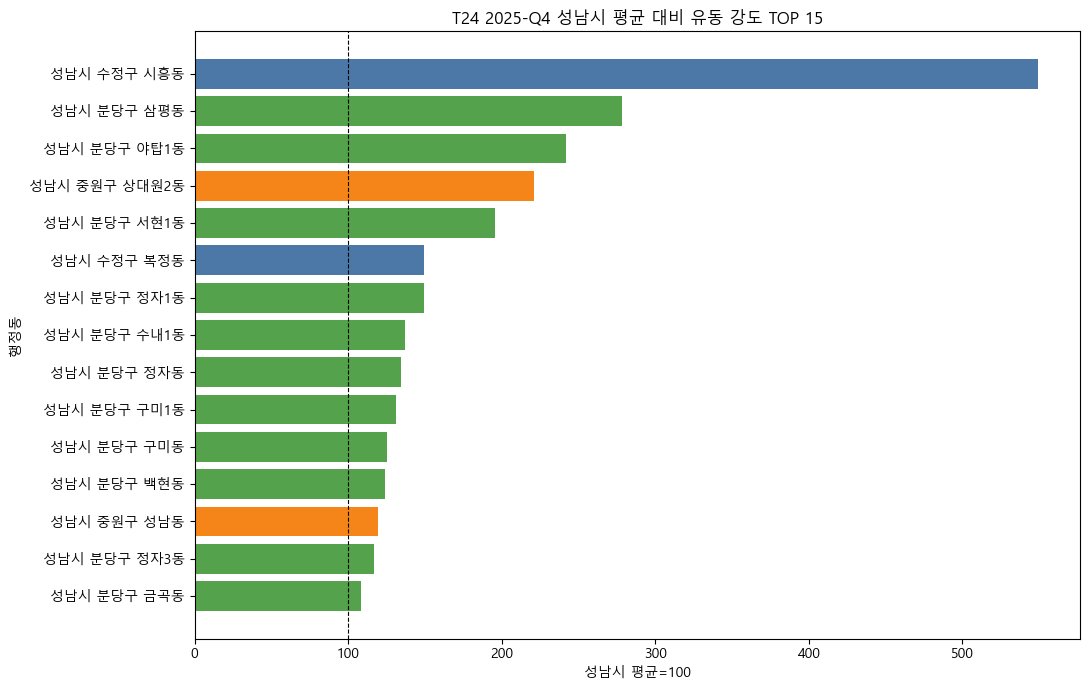

In [66]:
plot_signal = latest_signal.nlargest(15, "q_city_relative_flow_index").copy()

fig, ax = plt.subplots(figsize=(11, 7))
bar_colors = plot_signal["CTY_NM"].map(colors).fillna("#999999")
ax.barh(plot_signal["LABEL"][::-1], plot_signal["q_city_relative_flow_index"][::-1], color=bar_colors[::-1])
ax.axvline(100, color="black", linewidth=0.8, linestyle="--")
ax.set_title(f"T24 {latest_signal_label} 성남시 평균 대비 유동 강도 TOP 15")
ax.set_xlabel("성남시 평균=100")
ax.set_ylabel("행정동")
plt.tight_layout()
plt.show()

**그래프 설명 - 성남시 평균 대비 유동 강도**

100은 해당 분기 성남시 평균이다. 100보다 클수록 같은 인구 규모 대비 유동 관측이 큰 행정동이다. 단순 순위보다 평균 대비 몇 배인지가 보여서 발표나 변수 선택에 더 명확하다.

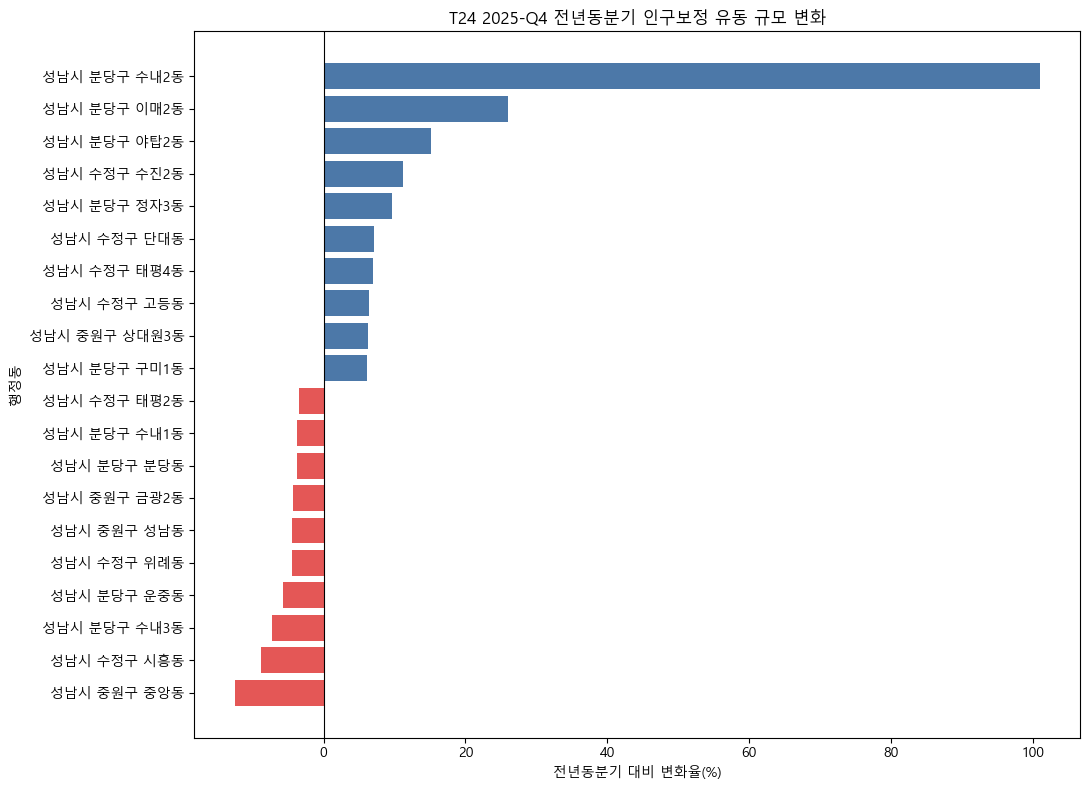

In [67]:
yoy_plot = latest_signal.dropna(subset=["q_yoy_cnt_per_1k_pct"]).copy()
yoy_plot = pd.concat(
    [
        yoy_plot.nlargest(10, "q_yoy_cnt_per_1k_pct").assign(TYPE="전년동분기 증가"),
        yoy_plot.nsmallest(10, "q_yoy_cnt_per_1k_pct").assign(TYPE="전년동분기 감소"),
    ],
    ignore_index=True,
).sort_values("q_yoy_cnt_per_1k_pct")

fig, ax = plt.subplots(figsize=(11, 8))
bar_colors = np.where(yoy_plot["q_yoy_cnt_per_1k_pct"] >= 0, "#4C78A8", "#E45756")
ax.barh(yoy_plot["LABEL"], yoy_plot["q_yoy_cnt_per_1k_pct"] * 100, color=bar_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"T24 {latest_signal_label} 전년동분기 인구보정 유동 규모 변화")
ax.set_xlabel("전년동분기 대비 변화율(%)")
ax.set_ylabel("행정동")
plt.tight_layout()
plt.show()

**그래프 설명 - 전년동분기 변화율**

전분기 변화율은 계절 영향을 받을 수 있어서, 같은 계절끼리 비교하는 전년동분기 변화율을 같이 본다. 증가율이 큰 지역은 최근 1년 사이 활동성이 커진 후보, 감소율이 큰 지역은 약해진 후보로 볼 수 있다.

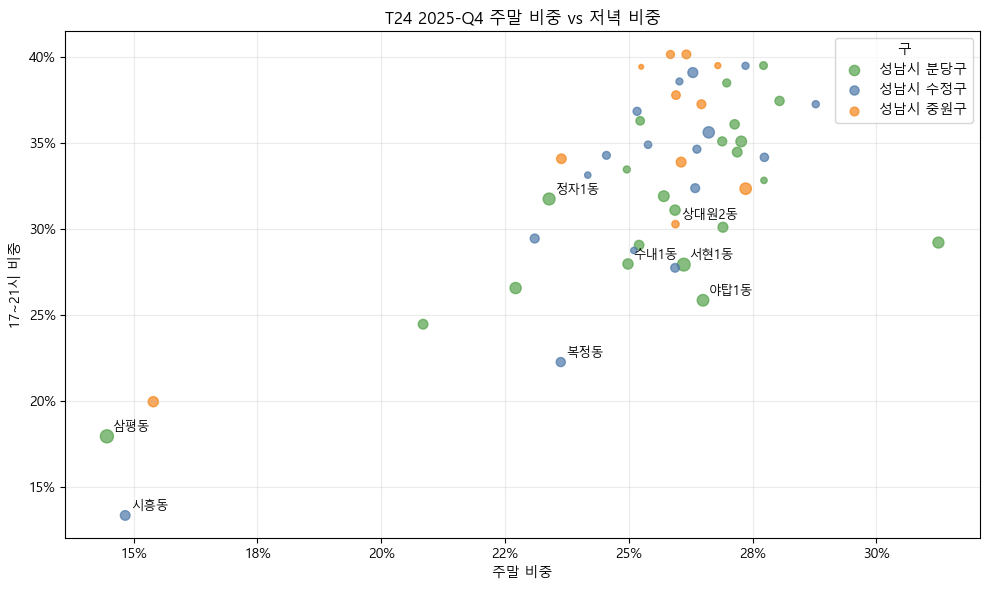

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))

for cty_name, sub in latest_signal.groupby("CTY_NM"):
    ax.scatter(
        sub["q_weekend_ratio"],
        sub["q_evening_ratio_detail"],
        s=np.sqrt(sub["CNT_SUM"]) / 35,
        alpha=0.7,
        label=cty_name,
        color=colors.get(cty_name, None),
    )

label_df = latest_signal.nlargest(8, "q_city_relative_flow_index")
for _, row in label_df.iterrows():
    ax.annotate(row["ADMI_NM"], (row["q_weekend_ratio"], row["q_evening_ratio_detail"]), fontsize=9, xytext=(4, 4), textcoords="offset points")

ax.set_title(f"T24 {latest_signal_label} 주말 비중 vs 저녁 비중")
ax.set_xlabel("주말 비중")
ax.xaxis.set_major_formatter(ratio_formatter)
ax.set_ylabel("17~21시 비중")
ax.yaxis.set_major_formatter(ratio_formatter)
ax.legend(title="구")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

**그래프 설명 - 주말 비중 vs 저녁 비중**

오른쪽 위에 가까울수록 주말과 저녁 활동이 모두 강한 지역이다. 상권·여가형 유동 후보를 찾을 때 총량보다 더 직관적인 보조지표가 된다.

### T22 성·연령·외국인 구성 지표

`T22`는 `M_20_CNT`, `F_30_CNT`처럼 성별·연령대 컬럼이 명확하게 나뉘어 있다. 그래서 생산가능·소비 가능 연령층 proxy는 `T24`의 `AGE_GRP`보다 `T22`에서 만드는 쪽이 더 안전하다.

여기서는 20~40대를 젠트리피케이션과 연결되는 소비·경제활동 연령층 후보로 보고, 고령층·외국인 비중과 함께 비교한다.

In [69]:
T22_MALE_COLS = [f"M_{age}_CNT" for age in [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]]
T22_FEMALE_COLS = [f"F_{age}_CNT" for age in [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]]
T22_ALL_COLS = T22_MALE_COLS + T22_FEMALE_COLS
T22_20_40_COLS = [f"{sex}_{age}_CNT" for sex in ["M", "F"] for age in [20, 25, 30, 35, 40]]
T22_60_PLUS_COLS = [f"{sex}_{age}_CNT" for sex in ["M", "F"] for age in [60, 65, 70]]

t22_total_expr = " + ".join([f"COALESCE({col}, 0)" for col in T22_ALL_COLS])
t22_male_expr = " + ".join([f"COALESCE({col}, 0)" for col in T22_MALE_COLS])
t22_female_expr = " + ".join([f"COALESCE({col}, 0)" for col in T22_FEMALE_COLS])
t22_20_40_expr = " + ".join([f"COALESCE({col}, 0)" for col in T22_20_40_COLS])
t22_60_plus_expr = " + ".join([f"COALESCE({col}, 0)" for col in T22_60_PLUS_COLS])
t22_d = "CAST(STRPTIME(CAST(ETL_YMD AS VARCHAR), '%Y%m%d') AS DATE)"

t22_quarterly_demo_panel = q(f'''
    SELECT
        {quarter_start_expr(t22_d)} AS QUARTER_START,
        {quarter_label_expr(t22_d)} AS base_quarter,
        CAST(ADMI_CD AS BIGINT) AS ADMI_CD,
        SUM({t22_total_expr}) AS T22_TOTAL_CNT,
        SUM({t22_male_expr}) AS T22_MALE_CNT,
        SUM({t22_female_expr}) AS T22_FEMALE_CNT,
        SUM({t22_20_40_expr}) AS T22_20_40_CNT,
        SUM({t22_60_plus_expr}) AS T22_60_PLUS_CNT,
        SUM(CASE WHEN FORN_GB = '외국인' THEN {t22_total_expr} ELSE 0 END) AS T22_FOREIGNER_CNT
    FROM {scan_sql("T22")}
    WHERE ADMI_CD IS NOT NULL
    GROUP BY 1, 2, 3
''')

t22_quarterly_demo_panel["QUARTER_START"] = pd.to_datetime(t22_quarterly_demo_panel["QUARTER_START"])
t22_quarterly_demo_panel = t22_quarterly_demo_panel.merge(
    population_quarterly[["QUARTER_START", "base_quarter", "ADMI_CD", "CTY_NM", "ADMI_NM", "TOTAL_POP"]],
    on=["QUARTER_START", "base_quarter", "ADMI_CD"],
    how="left",
)

t22_quarterly_demo_panel["q_t22_cnt_per_1k_pop"] = (
    t22_quarterly_demo_panel["T22_TOTAL_CNT"] / t22_quarterly_demo_panel["TOTAL_POP"] * 1000
)
t22_quarterly_demo_panel["q_t22_male_ratio"] = t22_quarterly_demo_panel["T22_MALE_CNT"] / t22_quarterly_demo_panel["T22_TOTAL_CNT"]
t22_quarterly_demo_panel["q_t22_female_ratio"] = t22_quarterly_demo_panel["T22_FEMALE_CNT"] / t22_quarterly_demo_panel["T22_TOTAL_CNT"]
t22_quarterly_demo_panel["q_t22_20_40_ratio"] = t22_quarterly_demo_panel["T22_20_40_CNT"] / t22_quarterly_demo_panel["T22_TOTAL_CNT"]
t22_quarterly_demo_panel["q_t22_60_plus_ratio"] = t22_quarterly_demo_panel["T22_60_PLUS_CNT"] / t22_quarterly_demo_panel["T22_TOTAL_CNT"]
t22_quarterly_demo_panel["q_t22_foreigner_ratio"] = t22_quarterly_demo_panel["T22_FOREIGNER_CNT"] / t22_quarterly_demo_panel["T22_TOTAL_CNT"]

t22_quarterly_demo_panel.head()

,QUARTER_START,base_quarter,ADMI_CD,T22_TOTAL_CNT,T22_MALE_CNT,T22_FEMALE_CNT,T22_20_40_CNT,T22_60_PLUS_CNT,T22_FOREIGNER_CNT,CTY_NM,ADMI_NM,TOTAL_POP,q_t22_cnt_per_1k_pop,q_t22_male_ratio,q_t22_female_ratio,q_t22_20_40_ratio,q_t22_60_plus_ratio,q_t22_foreigner_ratio
0,2025-04-01,2025-Q2,41135590,7945328.82,3686097.17,4259231.65,2535015.22,1697057.61,0.0,성남시 분당구,서현2동,17401.666667,456584.358969,0.463933,0.536067,0.319057,0.213592,0.0
1,2025-04-01,2025-Q2,41135610,2301816.06,1058601.02,1243215.04,691856.06,486028.87,0.0,성남시 분당구,이매2동,12929.333333,178030.529545,0.459898,0.540102,0.300570,0.211150,0.0
2,2025-04-01,2025-Q2,41135665,10909750.15,5078170.79,5831579.36,4412306.08,2369443.17,0.0,성남시 분당구,구미1동,16159.000000,675150.080451,0.465471,0.534529,0.404437,0.217186,0.0
3,2025-07-01,2025-Q3,41131590,4980136.74,2411564.22,2568572.52,1591851.90,1332481.61,0.0,성남시 수정구,단대동,14175.666667,351315.875091,0.484237,0.515763,0.319640,0.267559,0.0
4,2025-07-01,2025-Q3,41131600,2006809.88,1061535.15,945274.73,725652.16,547506.51,0.0,성남시 수정구,산성동,4477.333333,448215.428827,0.528966,0.471034,0.361595,0.272824,0.0


**데이터프레임 설명 - `t22_quarterly_demo_panel`**

`T22`를 분기·행정동 기준으로 집계해 성별, 연령대, 외국인 관측 비중을 만든 표다.

| 컬럼 | 왜 이렇게 구했는가 | 해석 |
|---|---|---|
| `q_t22_20_40_ratio` | M/F 20,25,30,35,40 컬럼 합 / 전체 | 주요 경제활동·소비 연령대 관측 비중 후보 |
| `q_t22_60_plus_ratio` | M/F 60,65,70 컬럼 합 / 전체 | 고령층 활동 비중 후보 |
| `q_t22_foreigner_ratio` | `FORN_GB='외국인'` 관측 합 / 전체 | 외국인 유동 비중 후보 |
| `q_t22_cnt_per_1k_pop` | T22 전체 관측 / 등록 인구 * 1000 | T22 기준 인구보정 활동 강도 |

In [70]:
latest_t22 = t22_quarterly_demo_panel[
    t22_quarterly_demo_panel["QUARTER_START"] == t22_quarterly_demo_panel["QUARTER_START"].max()
].copy()
latest_t22["LABEL"] = latest_t22["CTY_NM"] + " " + latest_t22["ADMI_NM"]

t22_signal_summary = pd.concat(
    [
        latest_t22.nlargest(10, "q_t22_20_40_ratio").assign(signal_type="20~40대 비중"),
        latest_t22.nlargest(10, "q_t22_60_plus_ratio").assign(signal_type="60대 이상 비중"),
        latest_t22.nlargest(10, "q_t22_foreigner_ratio").assign(signal_type="외국인 관측 비중"),
    ],
    ignore_index=True,
)

t22_signal_summary[
    [
        "signal_type", "base_quarter", "CTY_NM", "ADMI_NM",
        "q_t22_cnt_per_1k_pop", "q_t22_20_40_ratio",
        "q_t22_60_plus_ratio", "q_t22_foreigner_ratio",
    ]
].sort_values(["signal_type", "q_t22_cnt_per_1k_pop"], ascending=[True, False])

,signal_type,base_quarter,CTY_NM,ADMI_NM,q_t22_cnt_per_1k_pop,q_t22_20_40_ratio,q_t22_60_plus_ratio,q_t22_foreigner_ratio
1,20~40대 비중,2025-Q4,성남시 수정구,시흥동,2.955309e+06,0.593318,0.111774,0.0
0,20~40대 비중,2025-Q4,성남시 분당구,삼평동,1.625115e+06,0.626425,0.087478,0.0
6,20~40대 비중,2025-Q4,성남시 분당구,서현1동,9.333092e+05,0.462700,0.157010,0.0
5,20~40대 비중,2025-Q4,성남시 분당구,정자1동,8.033145e+05,0.466188,0.129786,0.0
2,20~40대 비중,2025-Q4,성남시 수정구,복정동,7.875554e+05,0.502924,0.148640,0.0
9,20~40대 비중,2025-Q4,성남시 분당구,정자동,6.860020e+05,0.428660,0.164698,0.0
8,20~40대 비중,2025-Q4,성남시 분당구,백현동,5.914093e+05,0.433407,0.179425,0.0
4,20~40대 비중,2025-Q4,성남시 수정구,태평1동,5.842051e+05,0.467820,0.228490,0.0
3,20~40대 비중,2025-Q4,성남시 수정구,고등동,5.014452e+05,0.495062,0.187222,0.0
7,20~40대 비중,2025-Q4,성남시 중원구,금광1동,3.674640e+05,0.436480,0.241848,0.0


**표 해석 - `t22_signal_summary`**

이 표는 이용자 구성에서 특징이 강한 행정동을 찾기 위한 표다. 예측 모델에서는 유동 총량만 넣는 것보다, “어떤 사람이 많이 관측되는가”를 함께 넣는 편이 지역 성격을 더 잘 설명할 수 있다.

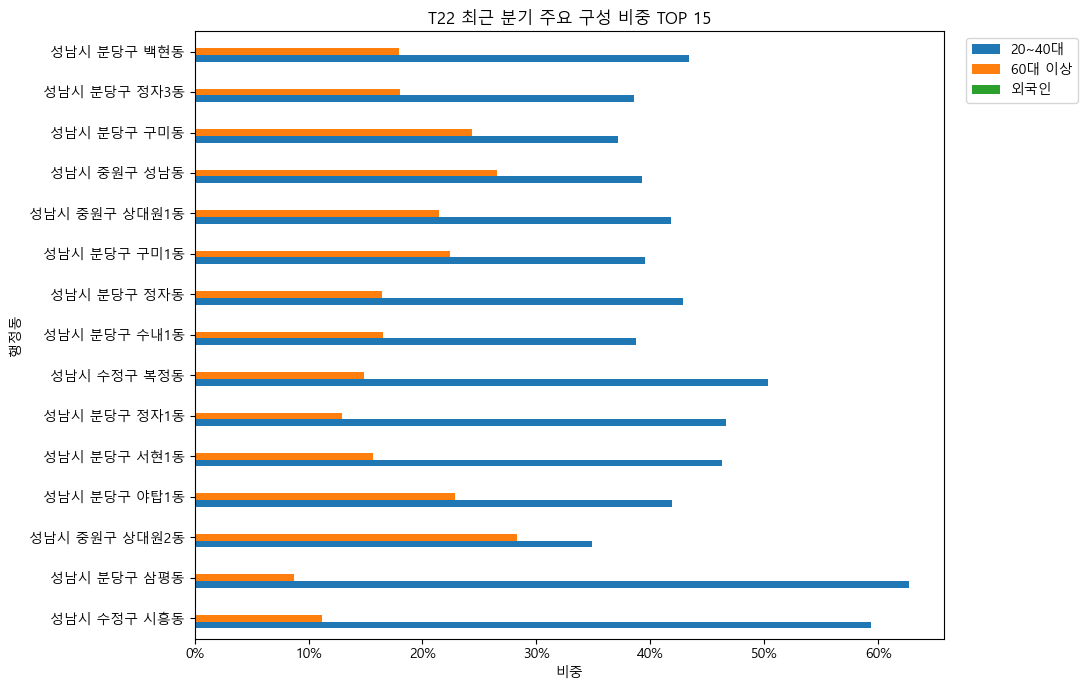

In [71]:
t22_stack_plot = latest_t22.nlargest(15, "q_t22_cnt_per_1k_pop").copy()
t22_stack_plot = t22_stack_plot.set_index("LABEL")[
    ["q_t22_20_40_ratio", "q_t22_60_plus_ratio", "q_t22_foreigner_ratio"]
]

ax = t22_stack_plot.plot(
    kind="barh",
    figsize=(11, 7),
    title="T22 최근 분기 주요 구성 비중 TOP 15",
)
ax.set_xlabel("비중")
ax.xaxis.set_major_formatter(ratio_formatter)
ax.set_ylabel("행정동")
ax.legend(["20~40대", "60대 이상", "외국인"], bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**그래프 설명 - T22 주요 구성 비중**

유동 규모가 큰 행정동 중 20~40대, 60대 이상, 외국인 관측 비중이 어떻게 다른지 비교한다. 같은 유동 규모라도 이용자 구성이 다르면 상권 성격이나 모델 영향이 달라질 수 있다.

### T22 생산가능·소비 가능 연령층 추가 시각화

위 그래프는 유동 규모가 큰 행정동을 기준으로 구성비를 비교한 것이다. 생산가능·소비 가능 연령층 자체가 높은 지역을 따로 보기 위해 `q_t22_20_40_ratio` 기준 TOP 행정동을 추가로 확인한다.

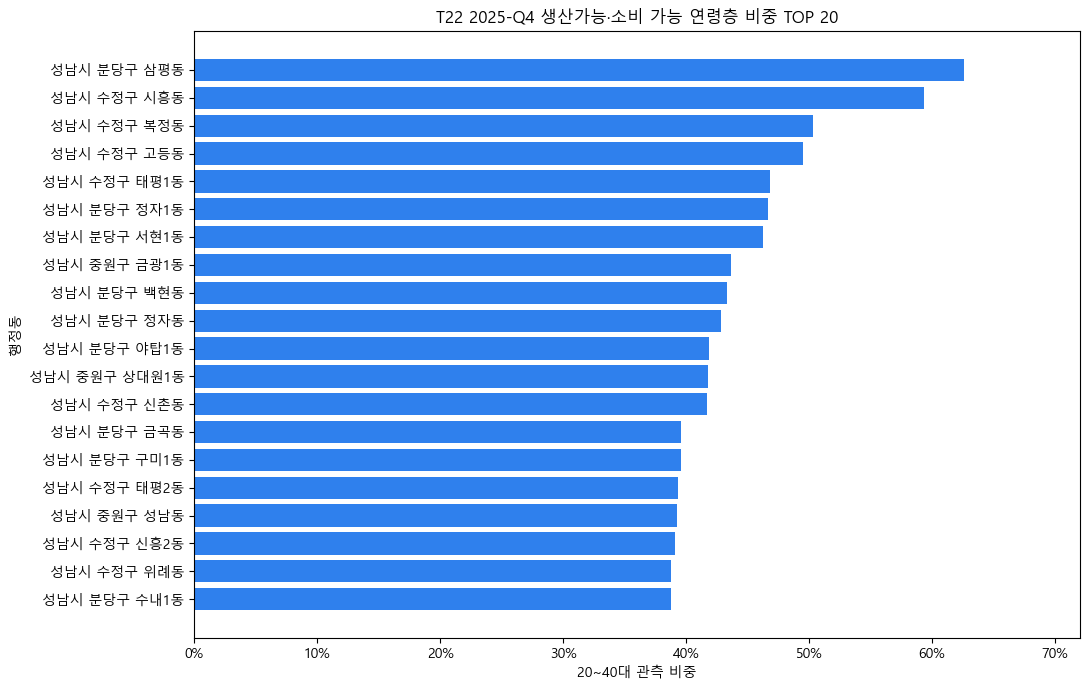

In [72]:
latest_t22_label = latest_t22["base_quarter"].iloc[0] if not latest_t22.empty else "최근 분기"

working_age_top = (
    latest_t22.dropna(subset=["q_t22_20_40_ratio"])
    .nlargest(20, "q_t22_20_40_ratio")
    .sort_values("q_t22_20_40_ratio")
)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(working_age_top["LABEL"], working_age_top["q_t22_20_40_ratio"], color="#2f80ed")
ax.set_title(f"T22 {latest_t22_label} 생산가능·소비 가능 연령층 비중 TOP 20")
ax.set_xlabel("20~40대 관측 비중")
ax.xaxis.set_major_formatter(ratio_formatter)
ax.set_ylabel("행정동")
ax.set_xlim(0, min(1, working_age_top["q_t22_20_40_ratio"].max() * 1.15))
plt.tight_layout()
plt.show()

**그래프 설명 - 생산가능·소비 가능 연령층 비중 TOP**

`20~40대 관측 비중`이 높은 행정동은 단순 유동 규모가 아니라 이용자 구성 측면에서 경제활동·소비 가능 연령층이 두드러지는 지역 후보로 본다. 젠트리피케이션 설명에서는 상권 변화, 신규 소비층 유입, 업무·여가 활동 증가와 연결해 해석할 수 있다.

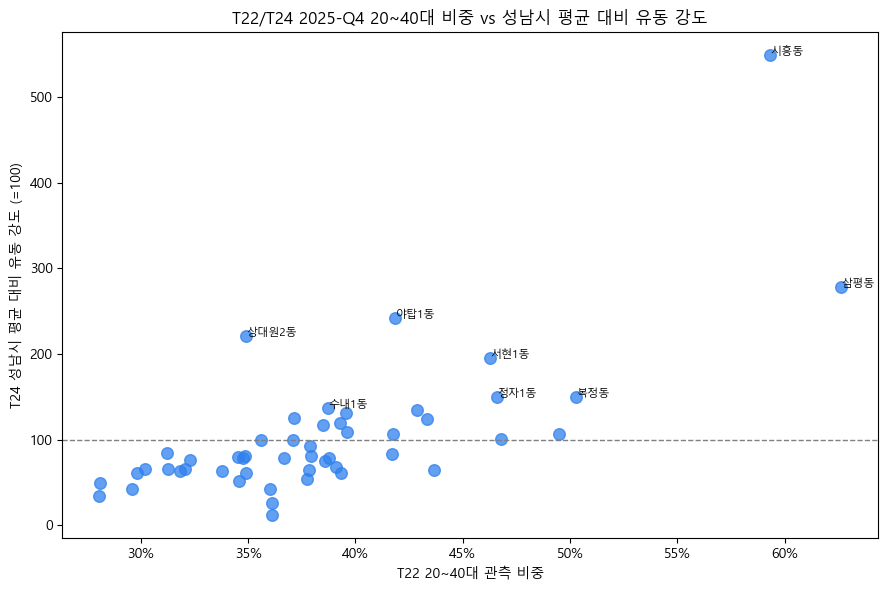

In [73]:
t22_t24_join = latest_t22.merge(
    latest_signal[["ADMI_CD", "q_city_relative_flow_index", "q_weekend_ratio", "q_evening_ratio_detail"]],
    on="ADMI_CD",
    how="left",
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    t22_t24_join["q_t22_20_40_ratio"],
    t22_t24_join["q_city_relative_flow_index"],
    s=70,
    alpha=0.75,
    color="#2f80ed",
)
ax.axhline(100, color="gray", linestyle="--", linewidth=1)
ax.set_title(f"T22/T24 {latest_t22_label} 20~40대 비중 vs 성남시 평균 대비 유동 강도")
ax.set_xlabel("T22 20~40대 관측 비중")
ax.xaxis.set_major_formatter(ratio_formatter)
ax.set_ylabel("T24 성남시 평균 대비 유동 강도 (=100)")
ax.yaxis.set_major_formatter(number_formatter)

label_df = t22_t24_join.nlargest(8, "q_city_relative_flow_index")
for _, row in label_df.iterrows():
    if pd.notna(row["q_t22_20_40_ratio"]) and pd.notna(row["q_city_relative_flow_index"]):
        ax.annotate(row["ADMI_NM"], (row["q_t22_20_40_ratio"], row["q_city_relative_flow_index"]), fontsize=8)

plt.tight_layout()
plt.show()

**그래프 설명 - 20~40대 비중 vs 유동 강도**

오른쪽 위에 가까운 행정동은 20~40대 구성비도 높고, 등록 인구 대비 유동 강도도 성남시 평균보다 큰 지역이다. 생산가능·소비 가능 연령층이 실제 지역 활동 강도와 같이 나타나는지 확인하는 교차 EDA다.

### T13 행정동 OD 외부유입 EDA

`T13`은 행정동 간 출발지-도착지 OD 구조가 있어서 외부유입과 유출을 직접 볼 수 있는 핵심 후보다. 파일이 매우 크므로 전체 행정동 전체 기간을 한 번에 그리지 않고, 최근 분기 `T24` 유동 강도 상위 행정동만 대상으로 경량 EDA를 실행한다.

이 지표는 “그 행정동 안에서 관측이 많다”를 넘어서, **외부에서 들어오는 이동인지 / 밖으로 나가는 이동인지**를 구분한다. 젠트리피케이션 맥락에서는 외부 수요가 특정 행정동으로 몰리는 압력 후보로 해석한다.

In [74]:
RUN_T13_OD_AUXILIARY_EDA = True
T13_OD_TOP_N = 20

if RUN_T13_OD_AUXILIARY_EDA:
    t13_d = date_expr("T13")
    od_codes = latest_signal.nlargest(T13_OD_TOP_N, "q_city_relative_flow_index")["ADMI_CD"].dropna().astype(int).tolist()
    od_codes_sql = ", ".join(map(str, od_codes))
    t13_q_start = pd.Timestamp(latest_signal_quarter)
    t13_q_end = t13_q_start + pd.DateOffset(months=3)

    t13_od_signal = q(f'''
        WITH od_scope AS (
            SELECT
                TRY_CAST(O_ADMI_CD AS BIGINT) AS O_ADMI_CD,
                TRY_CAST(D_ADMI_CD AS BIGINT) AS D_ADMI_CD,
                CNT
            FROM {scan_sql("T13")}
            WHERE {t13_d} >= DATE '{t13_q_start:%Y-%m-%d}'
              AND {t13_d} < DATE '{t13_q_end:%Y-%m-%d}'
              AND (
                    TRY_CAST(D_ADMI_CD AS BIGINT) IN ({od_codes_sql})
                 OR TRY_CAST(O_ADMI_CD AS BIGINT) IN ({od_codes_sql})
              )
        ),
        od_stack AS (
            SELECT
                D_ADMI_CD AS ADMI_CD,
                SUM(CNT) AS T13_INFLOW_CNT,
                SUM(CASE WHEN O_ADMI_CD <> D_ADMI_CD THEN CNT ELSE 0 END) AS T13_EXTERNAL_INFLOW_CNT,
                0::DOUBLE AS T13_OUTFLOW_CNT,
                0::DOUBLE AS T13_EXTERNAL_OUTFLOW_CNT
            FROM od_scope
            WHERE D_ADMI_CD IN ({od_codes_sql})
            GROUP BY 1

            UNION ALL

            SELECT
                O_ADMI_CD AS ADMI_CD,
                0::DOUBLE AS T13_INFLOW_CNT,
                0::DOUBLE AS T13_EXTERNAL_INFLOW_CNT,
                SUM(CNT) AS T13_OUTFLOW_CNT,
                SUM(CASE WHEN O_ADMI_CD <> D_ADMI_CD THEN CNT ELSE 0 END) AS T13_EXTERNAL_OUTFLOW_CNT
            FROM od_scope
            WHERE O_ADMI_CD IN ({od_codes_sql})
            GROUP BY 1
        )
        SELECT
            ADMI_CD,
            SUM(T13_INFLOW_CNT) AS T13_INFLOW_CNT,
            SUM(T13_EXTERNAL_INFLOW_CNT) AS T13_EXTERNAL_INFLOW_CNT,
            SUM(T13_OUTFLOW_CNT) AS T13_OUTFLOW_CNT,
            SUM(T13_EXTERNAL_OUTFLOW_CNT) AS T13_EXTERNAL_OUTFLOW_CNT
        FROM od_stack
        GROUP BY 1
    ''').fillna(0)

    t13_od_signal = t13_od_signal.merge(
        latest_signal[["ADMI_CD", "CTY_NM", "ADMI_NM", "TOTAL_POP"]],
        on="ADMI_CD",
        how="left",
    )
    t13_od_signal["LABEL"] = t13_od_signal["CTY_NM"] + " " + t13_od_signal["ADMI_NM"]
    t13_od_signal["q_t13_external_inflow_ratio"] = (
        t13_od_signal["T13_EXTERNAL_INFLOW_CNT"] / t13_od_signal["T13_INFLOW_CNT"].replace(0, np.nan)
    )
    t13_od_signal["q_t13_external_inflow_per_1k_pop"] = (
        t13_od_signal["T13_EXTERNAL_INFLOW_CNT"] / t13_od_signal["TOTAL_POP"] * 1000
    )
    t13_od_signal["q_t13_net_inflow_cnt"] = t13_od_signal["T13_INFLOW_CNT"] - t13_od_signal["T13_OUTFLOW_CNT"]
    t13_od_signal["q_t13_net_inflow_per_1k_pop"] = t13_od_signal["q_t13_net_inflow_cnt"] / t13_od_signal["TOTAL_POP"] * 1000
    t13_od_signal["q_t13_inflow_outflow_ratio"] = (
        t13_od_signal["T13_INFLOW_CNT"] / t13_od_signal["T13_OUTFLOW_CNT"].replace(0, np.nan)
    )
else:
    t13_od_signal = pd.DataFrame(
        {"안내": ["T13 OD 외부유입 EDA를 건너뜁니다. 필요하면 RUN_T13_OD_AUXILIARY_EDA=True로 바꾸세요."]}
    )

t13_od_signal.sort_values("q_t13_external_inflow_ratio", ascending=False) if "q_t13_external_inflow_ratio" in t13_od_signal.columns else t13_od_signal

,ADMI_CD,T13_INFLOW_CNT,T13_EXTERNAL_INFLOW_CNT,T13_OUTFLOW_CNT,T13_EXTERNAL_OUTFLOW_CNT,CTY_NM,ADMI_NM,TOTAL_POP,LABEL,q_t13_external_inflow_ratio,q_t13_external_inflow_per_1k_pop,q_t13_net_inflow_cnt,q_t13_net_inflow_per_1k_pop,q_t13_inflow_outflow_ratio
15,41133580,949572.16,885800.90,941202.31,877431.05,성남시 중원구,상대원2동,2923.333333,성남시 중원구 상대원2동,0.932842,303010.570125,8369.85,2863.118586,1.008893
5,41131650,2850138.00,2653811.90,2809615.19,2613289.09,성남시 수정구,시흥동,3533.666667,성남시 수정구 시흥동,0.931117,751007.989812,40522.81,11467.637959,1.014423
9,41131580,2096467.74,1943474.72,2069848.52,1916855.50,성남시 수정구,수진2동,14349.666667,성남시 수정구 수진2동,0.927023,135436.924435,26619.22,1855.041000,1.012860
19,41135545,2714956.59,2481247.46,2745038.10,2511328.97,성남시 분당구,정자동,13750.333333,성남시 분당구 정자동,0.913918,180449.986182,-30081.51,-2187.693147,0.989041
4,41131540,1997520.64,1818212.18,1954398.04,1775089.58,성남시 수정구,태평1동,13551.666667,성남시 수정구 태평1동,0.910234,134168.897799,43122.60,3182.088304,1.022064
10,41131530,1569490.18,1407637.01,1614171.33,1452318.16,성남시 수정구,신흥3동,10695.000000,성남시 수정구 신흥3동,0.896875,131616.363721,-44681.15,-4177.760636,0.972319
6,41135665,3101246.30,2745798.58,3181545.74,2826098.02,성남시 분당구,구미1동,16091.333333,성남시 분당구 구미1동,0.885386,170638.350665,-80299.44,-4990.229109,0.974761
2,41135657,4795205.57,4175126.91,4647366.42,4027287.76,성남시 분당구,백현동,26319.000000,성남시 분당구 백현동,0.870688,158635.469053,147839.15,5617.202401,1.031811
3,41135570,2825229.47,2456747.32,2895704.39,2527222.24,성남시 분당구,정자3동,16472.666667,성남시 분당구 정자3동,0.869574,149140.838561,-70474.92,-4278.294549,0.975662
1,41131620,2260840.17,1940778.16,2226154.77,1906092.76,성남시 수정구,복정동,10304.333333,성남시 수정구 복정동,0.858432,188345.824734,34685.40,3366.098405,1.015581


**T13 지표 해석**

`q_t13_external_inflow_ratio`는 해당 행정동 도착 이동 중 출발지가 다른 행정동인 비중이다. 높으면 외부 유입형 지역 후보로 볼 수 있다.

`q_t13_external_inflow_per_1k_pop`은 외부 행정동에서 들어온 유입량을 등록 인구로 보정한 값이다. 거주 인구 규모가 작은 행정동도 외부 방문 수요가 큰지 비교할 수 있다.

`q_t13_net_inflow_per_1k_pop`은 유입 CNT에서 유출 CNT를 뺀 뒤 등록 인구로 보정한 값이다. 양수면 들어오는 힘이 상대적으로 크고, 음수면 나가는 힘이 상대적으로 큰 후보로 해석한다.

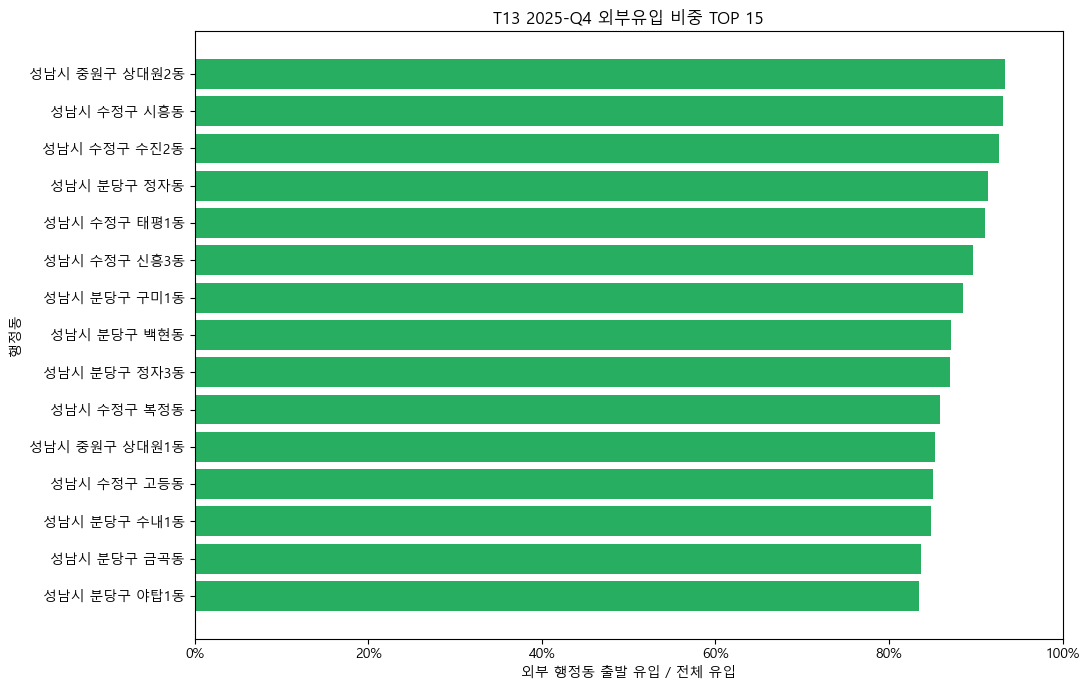

In [75]:
if "q_t13_external_inflow_ratio" in t13_od_signal.columns and not t13_od_signal.empty:
    t13_external_ratio_plot = (
        t13_od_signal.dropna(subset=["q_t13_external_inflow_ratio"])
        .nlargest(15, "q_t13_external_inflow_ratio")
        .sort_values("q_t13_external_inflow_ratio")
    )

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.barh(t13_external_ratio_plot["LABEL"], t13_external_ratio_plot["q_t13_external_inflow_ratio"], color="#27ae60")
    ax.set_title(f"T13 {latest_signal_label} 외부유입 비중 TOP 15")
    ax.set_xlabel("외부 행정동 출발 유입 / 전체 유입")
    ax.xaxis.set_major_formatter(ratio_formatter)
    ax.set_ylabel("행정동")
    ax.set_xlim(0, min(1, t13_external_ratio_plot["q_t13_external_inflow_ratio"].max() * 1.1))
    plt.tight_layout()
    plt.show()
else:
    display(pd.DataFrame({"안내": ["T13 외부유입 비중 그래프는 T13 OD EDA 실행 후 표시됩니다."]}))

**그래프 설명 - 외부유입 비중 TOP**

전체 유입 중 다른 행정동에서 출발한 이동이 차지하는 비중을 보여준다. 값이 높으면 해당 지역의 활동이 내부 거주자보다 외부 이동 수요와 더 강하게 연결된 후보로 볼 수 있다.

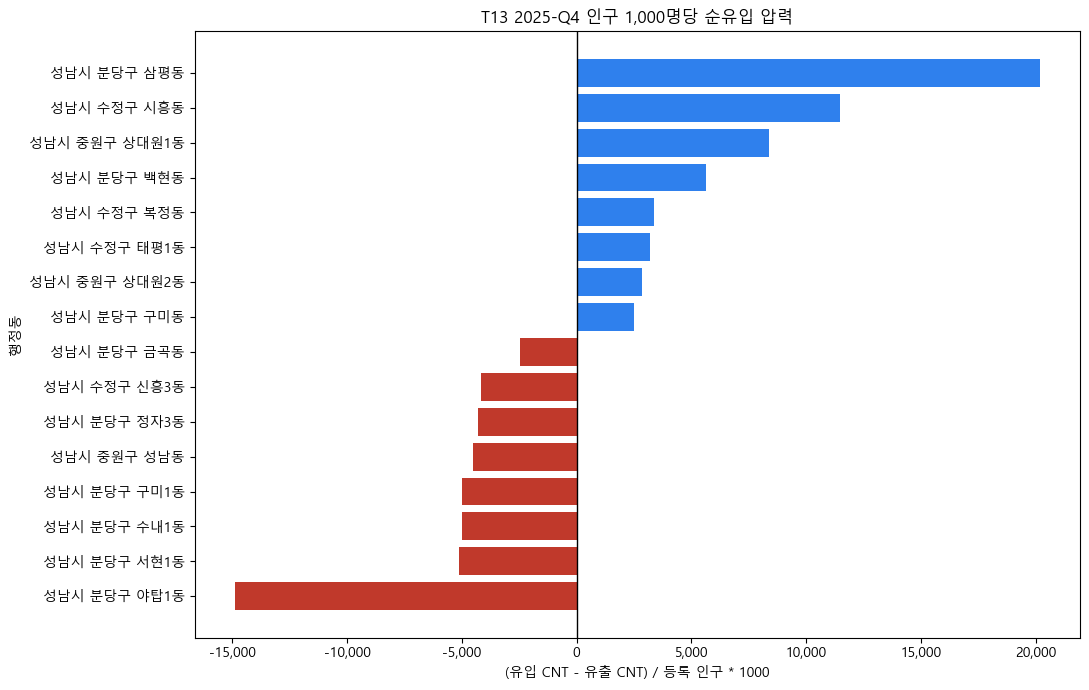

In [76]:
if "q_t13_net_inflow_per_1k_pop" in t13_od_signal.columns and not t13_od_signal.empty:
    t13_net_positive = t13_od_signal.nlargest(8, "q_t13_net_inflow_per_1k_pop")
    t13_net_negative = t13_od_signal.nsmallest(8, "q_t13_net_inflow_per_1k_pop")
    t13_net_plot = (
        pd.concat([t13_net_negative, t13_net_positive], ignore_index=True)
        .drop_duplicates(subset=["ADMI_CD"])
        .sort_values("q_t13_net_inflow_per_1k_pop")
    )

    colors = np.where(t13_net_plot["q_t13_net_inflow_per_1k_pop"] >= 0, "#2f80ed", "#c0392b")
    fig, ax = plt.subplots(figsize=(11, 7))
    ax.barh(t13_net_plot["LABEL"], t13_net_plot["q_t13_net_inflow_per_1k_pop"], color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"T13 {latest_signal_label} 인구 1,000명당 순유입 압력")
    ax.set_xlabel("(유입 CNT - 유출 CNT) / 등록 인구 * 1000")
    ax.xaxis.set_major_formatter(number_formatter)
    ax.set_ylabel("행정동")
    plt.tight_layout()
    plt.show()
else:
    display(pd.DataFrame({"안내": ["T13 순유입 그래프는 T13 OD EDA 실행 후 표시됩니다."]}))

**그래프 설명 - 인구 1,000명당 순유입 압력**

양수는 해당 분기 대상 행정동에서 유입이 유출보다 큰 상태, 음수는 유출이 더 큰 상태다. 등록 인구로 보정했기 때문에 단순 규모가 큰 행정동만 크게 보이는 문제를 줄인다.

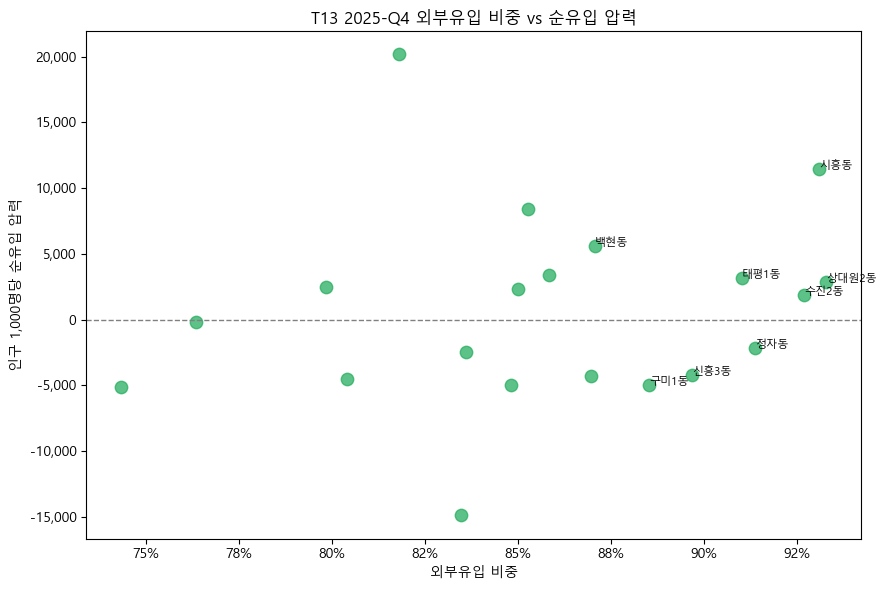

In [77]:
if {"q_t13_external_inflow_ratio", "q_t13_net_inflow_per_1k_pop"}.issubset(t13_od_signal.columns) and not t13_od_signal.empty:
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(
        t13_od_signal["q_t13_external_inflow_ratio"],
        t13_od_signal["q_t13_net_inflow_per_1k_pop"],
        s=80,
        alpha=0.75,
        color="#27ae60",
    )
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"T13 {latest_signal_label} 외부유입 비중 vs 순유입 압력")
    ax.set_xlabel("외부유입 비중")
    ax.xaxis.set_major_formatter(ratio_formatter)
    ax.set_ylabel("인구 1,000명당 순유입 압력")
    ax.yaxis.set_major_formatter(number_formatter)

    label_df = t13_od_signal.nlargest(8, "q_t13_external_inflow_ratio")
    for _, row in label_df.iterrows():
        if pd.notna(row["q_t13_external_inflow_ratio"]) and pd.notna(row["q_t13_net_inflow_per_1k_pop"]):
            ax.annotate(row["ADMI_NM"], (row["q_t13_external_inflow_ratio"], row["q_t13_net_inflow_per_1k_pop"]), fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    display(pd.DataFrame({"안내": ["T13 외부유입 산점도는 T13 OD EDA 실행 후 표시됩니다."]}))

**그래프 설명 - 외부유입 비중 vs 순유입 압력**

오른쪽 위에 가까울수록 외부에서 들어오는 비중도 높고, 유입이 유출보다 큰 행정동이다. 외부 수요가 강하게 들어오는 지역 후보를 한 번에 확인하기 위한 요약 시각화다.

### 추가 지표 중 우선 남길 후보

현재 단계에서 모델 후보로 가장 먼저 남길 만한 지표는 아래 순서다.

| 우선순위 | 지표 | 이유 |
|---|---|---|
| 1 | `q_city_relative_flow_index` | 성남시 평균=100이라 해석이 가장 직관적 |
| 2 | `q_yoy_cnt_per_1k_pct` | 계절성을 줄인 증가/감소 신호 |
| 3 | `q_weekend_ratio`, `q_evening_ratio_detail` | 상권·여가형 활동을 설명하기 좋음 |
| 4 | `q_nonroutine_visit_ratio_est` | 쇼핑/관광/병원 목적 추정 기반 방문성 보조지표 |
| 5 | `q_t22_20_40_ratio`, `q_t22_60_plus_ratio` | 이용자 구성 차이를 설명 |
| 6 | `q_t22_foreigner_ratio` | 특정 지역의 외국인 유동 특성 후보 |
| 7 | `q_t13_external_inflow_ratio`, `q_t13_external_inflow_per_1k_pop` | OD 외부유입 구조를 직접 설명하므로 범위를 제한해 사용 |

`PURPOSE`, `TRANS_GB`, `FORN_GB`는 실제 행동의 정답값이 아니라 통신 기반 분류/추정값이 섞여 있으므로, 최종 변수명에는 `_est` 또는 출처 표시를 남긴다.

## 분기 기준 1차 변수 후보 정리

아래 표는 현재 EDA를 바탕으로 한 **1차 변수 후보**다. 아직 모델링 변수 확정표가 아니라, 팀 공통 마스터 테이블이 정해지면 그 단위에 맞춰 다시 선택해야 한다.

In [78]:
quarter_feature_candidate_table = pd.DataFrame(
    [
        ["T24", "q_floating_pop_sum", "분기 CNT 합계", "행정동별 유동 규모 기본값"],
        ["T24", "q_cnt_per_1k_pop", "CNT_SUM / TOTAL_POP * 1000", "거주 인구 규모 보정 유동 강도"],
        ["T24", "q_city_relative_flow_index", "행정동 인구보정 유동 / 성남시 평균 * 100", "성남시 평균 대비 강도"],
        ["T24", "q_yoy_cnt_per_1k_pct", "전년동분기 CNT_PER_1K_POP 변화율", "계절성을 줄인 증가/감소 신호"],
        ["T24", "q_weekend_ratio", "주말 CNT / 전체 CNT", "주말형 상권·여가형 활동"],
        ["T24", "q_night_ratio", "0~5시 CNT / 전체 CNT", "야간 활동성"],
        ["T24", "q_lunch_ratio", "11~14시 CNT / 전체 CNT", "점심 시간대 활동성"],
        ["T24", "q_evening_ratio_detail", "17~21시 CNT / 전체 CNT", "퇴근 이후 활동성"],
        ["T24", "q_purpose_focus_ratio_est", "목적별 비중 중 최대값", "특정 목적 쏠림 정도"],
        ["T24", "q_nonroutine_visit_ratio_est", "쇼핑+관광+병원 추정 비중", "방문성 목적 보조지표"],
        ["T24", "q_shopping_visit_ratio_est", "PURPOSE=쇼핑 CNT / 전체 CNT", "추정 쇼핑 목적 보조지표"],
        ["T24", "q_tourism_visit_ratio_est", "PURPOSE=관광 CNT / 전체 CNT", "추정 관광 목적 보조지표"],
        ["T24/T26", "q_commercial_purpose_ratio_est", "쇼핑+관광 추정 비중", "상권 방문 성격 보조지표"],
        ["T22", "q_t22_20_40_ratio", "20~40대 성·연령 CNT / T22 전체 CNT", "주요 소비·경제활동 연령대 구성"],
        ["T22", "q_t22_60_plus_ratio", "60대 이상 성·연령 CNT / T22 전체 CNT", "고령층 활동 구성"],
        ["T22", "q_t22_foreigner_ratio", "외국인 FORN_GB CNT / T22 전체 CNT", "외국인 유동 구성"],
        ["T26", "q_avg_stay_time_est", "DURATION의 CNT 가중평균", "체류형 상권 여부 보조지표"],
        ["T26", "q_public_transport_ratio_est", "버스+지하철 추정 비중", "대중교통 접근성 보조지표"],
        ["T26", "q_car_ratio_est", "차량 추정 비중", "차량 접근성/의존도 보조지표"],
        ["T26", "q_walk_ratio_est", "도보 추정 비중", "도보 접근성 보조지표"],
        ["T13", "q_t13_external_inflow_ratio", "외부 행정동 출발 유입 / 전체 유입", "외부 유입형 지역 후보"],
        ["T13", "q_t13_external_inflow_per_1k_pop", "외부유입 CNT / 인구 * 1000", "인구 보정 외부유입 압력 후보"],
        ["T13", "q_t13_net_inflow_per_1k_pop", "(유입-유출) / 인구 * 1000", "순유입 압력 후보"],
        ["T25", "q_city_inflow_pressure", "시군구 OD 유입 압력", "구 단위 보조 후보"],
    ],
    columns=["원천", "변수 후보", "생성 기준", "사용 방향"],
)

quarter_feature_candidate_table

,원천,변수 후보,생성 기준,사용 방향
0,T24,q_floating_pop_sum,분기 CNT 합계,행정동별 유동 규모 기본값
1,T24,q_cnt_per_1k_pop,CNT_SUM / TOTAL_POP * 1000,거주 인구 규모 보정 유동 강도
2,T24,q_city_relative_flow_index,행정동 인구보정 유동 / 성남시 평균 * 100,성남시 평균 대비 강도
3,T24,q_yoy_cnt_per_1k_pct,전년동분기 CNT_PER_1K_POP 변화율,계절성을 줄인 증가/감소 신호
4,T24,q_weekend_ratio,주말 CNT / 전체 CNT,주말형 상권·여가형 활동
5,T24,q_night_ratio,0~5시 CNT / 전체 CNT,야간 활동성
6,T24,q_lunch_ratio,11~14시 CNT / 전체 CNT,점심 시간대 활동성
7,T24,q_evening_ratio_detail,17~21시 CNT / 전체 CNT,퇴근 이후 활동성
8,T24,q_purpose_focus_ratio_est,목적별 비중 중 최대값,특정 목적 쏠림 정도
9,T24,q_nonroutine_visit_ratio_est,쇼핑+관광+병원 추정 비중,방문성 목적 보조지표


In [79]:
quarter_modeling_plan = pd.DataFrame(
    [
        ["1순위", "T24", "base_quarter + ADMI_CD", "행정동 분기별 기본 유동/시간대/목적 지표"],
        ["2순위", "T26", "base_quarter + D_ADMI_CD", "도착 행정동 기준 체류시간, 이동수단, 목적 보조지표"],
        ["3순위", "T27", "base_quarter + O_ADMI_CD", "출발 행정동 기준 이동수단/목적 보조지표"],
        ["검토", "T13", "base_quarter + O_ADMI_CD/D_ADMI_CD", "행정동 OD 유입/유출 구조"],
        ["보조", "T25", "base_quarter + 시군구 코드", "시군구 단위 유입 압력 보조"],
    ],
    columns=["우선순위", "테이블", "결합 키 후보", "역할"],
)

quarter_modeling_plan

,우선순위,테이블,결합 키 후보,역할
0,1순위,T24,base_quarter + ADMI_CD,행정동 분기별 기본 유동/시간대/목적 지표
1,2순위,T26,base_quarter + D_ADMI_CD,"도착 행정동 기준 체류시간, 이동수단, 목적 보조지표"
2,3순위,T27,base_quarter + O_ADMI_CD,출발 행정동 기준 이동수단/목적 보조지표
3,검토,T13,base_quarter + O_ADMI_CD/D_ADMI_CD,행정동 OD 유입/유출 구조
4,보조,T25,base_quarter + 시군구 코드,시군구 단위 유입 압력 보조


## 정리 메모

- 월별 EDA는 백업 파일에 남겨두고, 이 노트북은 분기별 EDA를 중심으로 본다.
- 기본 흐름은 `T24 분기별 행정동 패널 -> 인구 보정 시각화 -> PURPOSE 보조지표 -> T22 성·연령 구성 -> T26 이동수단/체류 보조지표 -> T13/T25 외부유입 후보`다.
- `T24`만 사용한 것이 아니라, `T22`는 생산가능·소비 가능 연령층 구성, `T26`은 체류·교통수단, `T13/T25`는 외부유입 압력, `T27`은 출발지 기준 보조 후보로 역할을 나눠 관리한다.
- `PURPOSE`, `TRANS_GB`는 코드 정의는 확인했지만 통신사 추정값이므로 변수명에 `_est`를 붙여 보조지표로 관리한다.
- 아직 최종 테이블 확정이 아니므로, 위 변수들은 모델링 1차 후보로만 둔다.